In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT / "src"))

from bdtools.io import run_etl

In [2]:
df, calidad_datos = run_etl()

df.head()

,id_caso,anio,mes,dia,codigo_dane_de_municipio,municipio,departamento,region,modalidad,presunto_responsable,...,forma_de_vinculacion,tipo_de_vinculacion,latitud_longitud,anio_valido,mes_valido,dia_valido,longitud,latitud,decada,total_hechos
0,152.888,2.004,4,0,05585,PUERTO NARE,ANTIOQUIA,MAGDALENA MEDIO,PERSUASIÓN,GRUPO PARAMILITAR,...,SIN INFORMACIÓN,RECLUTAMIENTO,POINT (-74.5716887665 6.2194810893),2.004,4.0,NaN,-74.571689,6.219481,0s,1
1,207.556,2.001,4,25,05756,SONSON,ANTIOQUIA,ORIENTE ANTIOQUEÑO,PERSUASIÓN,GRUPO PARAMILITAR,...,INDIVIDUAL,RECLUTAMIENTO,POINT (-74.82807326 5.837681474),2.001,4.0,25.0,-74.828073,5.837681,0s,1
2,209.268,0.000,0,0,05234,DABEIBA,ANTIOQUIA,OCCIDENTE ANTIOQUEÑO,DESCONOCIDA,GUERRILLA,...,INDIVIDUAL,RECLUTAMIENTO,POINT (-76.31426328 6.992243782),NaN,NaN,NaN,-76.314263,6.992244,SIN FECHA,0
3,225.057,1.988,0,0,68689,SAN VICENTE DE CHUCURI,SANTANDER,MAGDALENA MEDIO,COACCIÓN,GUERRILLA,...,INDIVIDUAL,RECLUTAMIENTO,POINT (-73.53900334 6.894292346),1.988,NaN,NaN,-73.539003,6.894292,0s,0
4,228.661,1.998,2,15,66456,MISTRATO,RISARALDA,EJE CAFETERO,PERSUASIÓN,GUERRILLA,...,INDIVIDUAL,RECLUTAMIENTO,POINT (-75.90432634 5.416268487),1.998,2.0,15.0,-75.904326,5.416268,0s,0


In [3]:
calidad_datos.head(10)

,columna,tipo,nulos,porcentaje_nulos,valores_unicos,registros
0,dia_valido,float64,11967,69.57,31,17201
1,mes_valido,float64,11578,67.31,12,17201
2,anio_valido,float64,11176,64.97,50,17201
3,dia,int64,0,0.00,32,17201
4,id_caso,float64,0,0.00,17201,17201
5,anio,float64,0,0.00,51,17201
6,mes,int64,0,0.00,13,17201
7,region,string,0,0.00,76,17201
8,modalidad,string,0,0.00,5,17201
9,presunto_responsable,string,0,0.00,11,17201


In [ ]:
# ── 1.3 Carga del dataset ──────────────────────────────────
# Sube el archivo desde tu computador cuando Colab lo pida
from google.colab import files
uploaded = files.upload()  # selecciona Caso_Conflicto_Armado.xlsx

df = pd.read_excel('/content/drive/MyDrive/Proyecto final Big data/Caso_Conflicto_Armado.xlsx')
print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")


Saving Caso_Conflicto_Armado.xlsx to Caso_Conflicto_Armado (1).xlsx
✅ Dataset cargado: 17,201 filas × 27 columnas


In [ ]:
# ── 1.4 Vista general ──────────────────────────────────────
print("\n📋 PRIMERAS 5 FILAS")
display(df.head())

print("\n📐 DIMENSIONES:", df.shape)

print("\n🔠 TIPOS DE DATOS")
display(df.dtypes.rename('Tipo').to_frame())


📋 PRIMERAS 5 FILAS


,ID Caso,ID Caso Relacionado,Año,Mes,Día,Código DANE de Municipio,Municipio,Departamento,Región,Modalidad,...,Extorsión,Lesionados Civiles,Pillaje,Tortura,Violencia Basada en Género,Otro Hecho Simultáneo,Total de Víctimas del Caso,Forma de Vinculación,Tipo de Vinculación,latitud-longitud
0,152888,NaN,2004,4,0,05585,PUERTO NARE,ANTIOQUIA,MAGDALENA MEDIO,PERSUASIÓN,...,0,0,0,0,NaN,NaN,1,SIN INFORMACIÓN,RECLUTAMIENTO,POINT (-74.5716887665 6.2194810893)
1,207556,NaN,2001,4,25,05756,SONSON,ANTIOQUIA,ORIENTE ANTIOQUEÑO,PERSUASIÓN,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-74.82807326 5.837681474)
2,209268,NaN,0,0,0,05234,DABEIBA,ANTIOQUIA,OCCIDENTE ANTIOQUEÑO,DESCONOCIDA,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-76.31426328 6.992243782)
3,225057,NaN,1988,0,0,68689,SAN VICENTE DE CHUCURI,SANTANDER,MAGDALENA MEDIO,COACCIÓN,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-73.53900334 6.894292346)
4,228661,NaN,1998,2,15,66456,MISTRATO,RISARALDA,EJE CAFETERO,PERSUASIÓN,...,0,0,0,0,NaN,OCULTAMIENTO DE CADÁVER,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-75.90432634 5.416268487)



📐 DIMENSIONES: (17201, 27)

🔠 TIPOS DE DATOS


,Tipo
ID Caso,int64
ID Caso Relacionado,object
Año,int64
Mes,int64
Día,int64
Código DANE de Municipio,object
Municipio,object
Departamento,object
Región,object
Modalidad,object


In [ ]:
# ── 1.5 Mapa de nulos ──────────────────────────────────────
nulos = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    '% Nulos':    (df.isnull().sum() / len(df) * 100).round(2),
    'No Nulos':   df.notnull().sum(),
    'Tipo':       df.dtypes
}).sort_values('% Nulos', ascending=False)

print("\n🕳️ REPORTE DE VALORES NULOS")
display(nulos)



🕳️ REPORTE DE VALORES NULOS


,Nulos,% Nulos,No Nulos,Tipo
Violencia Basada en Género,17193,99.95,8,object
Otro Hecho Simultáneo,17165,99.79,36,object
ID Caso Relacionado,16831,97.85,370,object
Región,27,0.16,17174,object
Mes,0,0.00,17201,int64
Año,0,0.00,17201,int64
Día,0,0.00,17201,int64
Municipio,0,0.00,17201,object
Departamento,0,0.00,17201,object
Código DANE de Municipio,0,0.00,17201,object


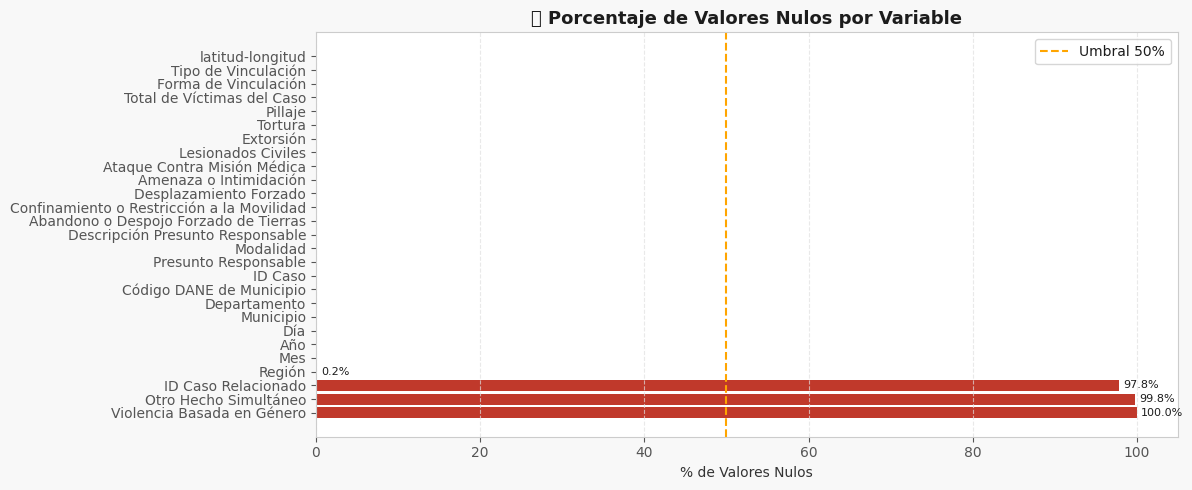

In [ ]:
# ── 1.6 Visualización del mapa de nulos ────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
nulos_pct = nulos['% Nulos']
bars = ax.barh(nulos_pct.index, nulos_pct.values,
               color=[RED if v > 50 else BLUE for v in nulos_pct.values])
ax.set_xlabel('% de Valores Nulos')
ax.set_title('🕳️ Porcentaje de Valores Nulos por Variable', fontweight='bold', fontsize=13)
ax.axvline(50, color='orange', linestyle='--', linewidth=1.5, label='Umbral 50%')
ax.legend()
for bar, v in zip(bars, nulos_pct.values):
    if v > 0:
        ax.text(v + 0.5, bar.get_y() + bar.get_height()/2,
                f'{v:.1f}%', va='center', fontsize=8)
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()


Saving Caso_Conflicto_Armado.xlsx to Caso_Conflicto_Armado.xlsx
✅ Dataset cargado: 17,201 filas × 27 columnas

📋 PRIMERAS 5 FILAS


,ID Caso,ID Caso Relacionado,Año,Mes,Día,Código DANE de Municipio,Municipio,Departamento,Región,Modalidad,...,Extorsión,Lesionados Civiles,Pillaje,Tortura,Violencia Basada en Género,Otro Hecho Simultáneo,Total de Víctimas del Caso,Forma de Vinculación,Tipo de Vinculación,latitud-longitud
0,152888,NaN,2004,4,0,05585,PUERTO NARE,ANTIOQUIA,MAGDALENA MEDIO,PERSUASIÓN,...,0,0,0,0,NaN,NaN,1,SIN INFORMACIÓN,RECLUTAMIENTO,POINT (-74.5716887665 6.2194810893)
1,207556,NaN,2001,4,25,05756,SONSON,ANTIOQUIA,ORIENTE ANTIOQUEÑO,PERSUASIÓN,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-74.82807326 5.837681474)
2,209268,NaN,0,0,0,05234,DABEIBA,ANTIOQUIA,OCCIDENTE ANTIOQUEÑO,DESCONOCIDA,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-76.31426328 6.992243782)
3,225057,NaN,1988,0,0,68689,SAN VICENTE DE CHUCURI,SANTANDER,MAGDALENA MEDIO,COACCIÓN,...,0,0,0,0,NaN,NaN,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-73.53900334 6.894292346)
4,228661,NaN,1998,2,15,66456,MISTRATO,RISARALDA,EJE CAFETERO,PERSUASIÓN,...,0,0,0,0,NaN,OCULTAMIENTO DE CADÁVER,1,INDIVIDUAL,RECLUTAMIENTO,POINT (-75.90432634 5.416268487)



📐 DIMENSIONES: (17201, 27)

🔠 TIPOS DE DATOS


,Tipo
ID Caso,int64
ID Caso Relacionado,object
Año,int64
Mes,int64
Día,int64
Código DANE de Municipio,object
Municipio,object
Departamento,object
Región,object
Modalidad,object



🕳️ REPORTE DE VALORES NULOS


,Nulos,% Nulos,No Nulos,Tipo
Violencia Basada en Género,17193,99.95,8,object
Otro Hecho Simultáneo,17165,99.79,36,object
ID Caso Relacionado,16831,97.85,370,object
Región,27,0.16,17174,object
Mes,0,0.00,17201,int64
Año,0,0.00,17201,int64
Día,0,0.00,17201,int64
Municipio,0,0.00,17201,object
Departamento,0,0.00,17201,object
Código DANE de Municipio,0,0.00,17201,object


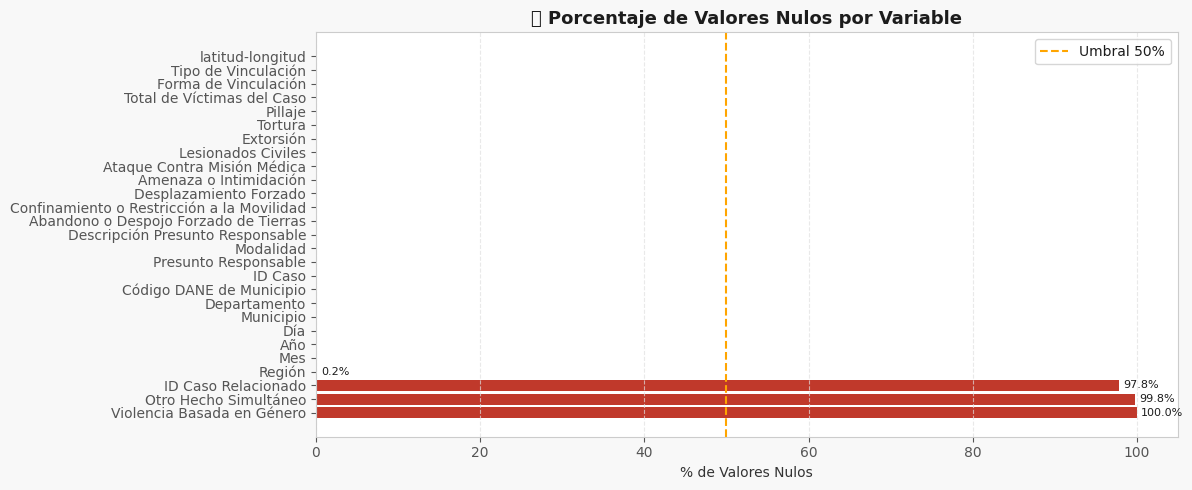


♻️ Registros duplicados: 0
   IDs únicos de caso:   17,201

📊 ESTADÍSTICAS DESCRIPTIVAS — Variables numéricas


,count,mean,std,min,25%,50%,75%,max
ID Caso,17201.0,328343.72,82933.68,35787.0,306640.0,311342.0,315896.0,878753.0
Año,17201.0,702.11,956.28,0.0,0.0,0.0,2002.0,2024.0
Mes,17201.0,1.98,3.52,0.0,0.0,0.0,2.0,12.0
Día,17201.0,3.65,7.68,0.0,0.0,0.0,1.0,31.0
Abandono o Despojo Forzado de Tierras,17201.0,0.00,0.03,0.0,0.0,0.0,0.0,1.0
Amenaza o Intimidación,17201.0,0.01,0.11,0.0,0.0,0.0,0.0,1.0
Ataque Contra Misión Médica,17201.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
Confinamiento o Restricción a la Movilidad,17201.0,0.00,0.02,0.0,0.0,0.0,0.0,1.0
Desplazamiento Forzado,17201.0,0.01,0.08,0.0,0.0,0.0,0.0,1.0
Extorsión,17201.0,0.00,0.02,0.0,0.0,0.0,0.0,1.0


In [ ]:
# ── 1.8 Resumen rápido ─────────────────────────────────────
print("\n📊 ESTADÍSTICAS DESCRIPTIVAS — Variables numéricas")
display(df.describe().T.round(2))

In [ ]:
# ── 1.7 Duplicados ─────────────────────────────────────────
dup = df.duplicated().sum()
print(f"\n♻️ Registros duplicados: {dup}")
print(f"   IDs únicos de caso:   {df['ID Caso'].nunique():,}")



♻️ Registros duplicados: 0
   IDs únicos de caso:   17,201


#SECCIÓN 2 — LIMPIEZA Y PREPROCESAMIENTO

Se aplicó una estrategia mixta de limpieza basada en
el diagnóstico de la Sección 1:

→ Se eliminaron 3 columnas con más del 90% de nulos:
  ID Caso Relacionado (97.8%), Violencia Basada en
  Género (100%) y Otro Hecho Simultáneo (99.8%),
  al considerarse irrelevantes para el análisis.

→ Se imputaron los 27 nulos de la variable Región
  cruzando cada registro con el modo de región
  correspondiente a su Departamento.

→ Los valores Año=0, Mes=0 y Día=0 se convirtieron
  a NaN conservando los registros originales. Se creó
  df_temporal con los 6,025 registros que sí tienen
  fecha válida para el análisis temporal.

→ Se estandarizaron todas las variables de texto
  a mayúsculas y sin espacios adicionales.

→ Se extrajeron las coordenadas de latitud y longitud
  de la columna latitud-longitud para el análisis
  geoespacial. Se obtuvo 14,776 registros con
  coordenadas válidas (85.9% del total).

→ Se creó la variable Década para agrupaciones
  temporales.

Resultado final: 17,201 filas × 30 columnas
(24 originales + 6 columnas derivadas creadas).


In [ ]:
# SECCIÓN 2: LIMPIEZA Y PREPROCESAMIENTO
# ============================================================

# ── 2.1 Eliminar columnas con >90% de nulos ────────────────
umbral_nulos = 90

cols_eliminar = [col for col in df.columns
                 if df[col].isnull().sum() / len(df) * 100 > umbral_nulos]

print(f"🗑️ Columnas eliminadas por >90% nulos ({len(cols_eliminar)}):")
for col in cols_eliminar:
    pct = df[col].isnull().sum() / len(df) * 100
    print(f"   • {col:45s} → {pct:.1f}% nulos")

df.drop(columns=cols_eliminar, inplace=True)
print(f"\n✅ Dataset después de eliminar columnas: {df.shape[0]:,} filas × {df.shape[1]} columnas")

🗑️ Columnas eliminadas por >90% nulos (3):
   • ID Caso Relacionado                           → 97.8% nulos
   • Violencia Basada en Género                    → 100.0% nulos
   • Otro Hecho Simultáneo                         → 99.8% nulos

✅ Dataset después de eliminar columnas: 17,201 filas × 24 columnas


In [ ]:
# ── 2.2 Imputar Región (0.16% nulos) ──────────────────────
# Cruzamos Departamento → Región más frecuente para ese depto
region_por_depto = (df[df['Región'].notna()]
                    .groupby('Departamento')['Región']
                    .agg(lambda x: x.mode()[0] if len(x) > 0 else 'SIN INFORMACION'))

df['Región'] = df.apply(
    lambda row: region_por_depto.get(row['Departamento'], 'SIN INFORMACION')
    if pd.isnull(row['Región']) else row['Región'],
    axis=1
)
print(f"\n✅ Nulos en 'Región' tras imputación: {df['Región'].isnull().sum()}")


✅ Nulos en 'Región' tras imputación: 0


In [ ]:
# ── 2.3 Tratar nulos implícitos en fechas ─────────────────
# Año, Mes, Día = 0 significa "sin información", NO son ceros reales
df['Año_valido']  = df['Año'].apply(lambda x: x if x > 0 else np.nan)
df['Mes_valido']  = df['Mes'].apply(lambda x: x if x > 0 else np.nan)
df['Dia_valido']  = df['Día'].apply(lambda x: x if x > 0 else np.nan)

sin_fecha = (df['Año'] == 0).sum()
print(f"\n📅 Registros sin fecha (Año=0): {sin_fecha:,} ({sin_fecha/len(df)*100:.1f}%)")
print(f"   → Se conservan en el dataset pero se excluyen del análisis temporal")


📅 Registros sin fecha (Año=0): 11,176 (65.0%)
   → Se conservan en el dataset pero se excluyen del análisis temporal


In [ ]:
# ── 2.4 Crear dataset limpio para análisis temporal ───────
df_temporal = df[df['Año_valido'].notna()].copy()
print(f"\n📆 Registros con fecha válida: {len(df_temporal):,}")


📆 Registros con fecha válida: 6,025


In [ ]:
# ── 2.5 Estandarizar textos categóricos ───────────────────
cols_texto = ['Departamento', 'Municipio', 'Región',
              'Modalidad', 'Presunto Responsable',
              'Tipo de Vinculación', 'Forma de Vinculación']

for col in cols_texto:
    df[col] = df[col].astype(str).str.strip().str.upper()

print("\n✅ Variables de texto estandarizadas (mayúsculas + sin espacios)")



✅ Variables de texto estandarizadas (mayúsculas + sin espacios)


In [ ]:
# ── 2.6 Extraer coordenadas de la columna latitud-longitud ─
import re

def extraer_coords(punto):
    try:
        nums = re.findall(r'-?\d+\.\d+', str(punto))
        if len(nums) == 2:
            return float(nums[0]), float(nums[1])
    except:
        pass
    return np.nan, np.nan

df[['longitud', 'latitud']] = df['latitud-longitud'].apply(
    lambda x: pd.Series(extraer_coords(x))
)

coords_ok = df['latitud'].notna().sum()
print(f"\n🌍 Coordenadas extraídas exitosamente: {coords_ok:,} de {len(df):,} registros")



🌍 Coordenadas extraídas exitosamente: 14,776 de 17,201 registros


In [ ]:
# ── 2.7 Columna de década ──────────────────────────────────
df['Década'] = df['Año_valido'].apply(
    lambda x: f"{int(x)//10*10}s" if pd.notna(x) else 'Sin fecha'
)

print(f"\n🕐 Distribución por década:")
print(df['Década'].value_counts().sort_index().to_string())


🕐 Distribución por década:
Década
1960s            2
1970s            9
1980s           64
1990s          519
2000s         4444
2010s          941
2020s           46
Sin fecha    11176


In [ ]:
# ── 2.8 Definir columnas de hechos victimizantes ──────────
HECHOS_COLS = [
    'Abandono o Despojo Forzado de Tierras',
    'Amenaza o Intimidación',
    'Ataque Contra Misión Médica',
    'Confinamiento o Restricción a la Movilidad',
    'Desplazamiento Forzado',
    'Extorsión',
    'Lesionados Civiles',
    'Pillaje',
    'Tortura',
]

HECHOS_LABELS = [
    'Abandono/Despojo',
    'Amenaza/Intimidación',
    'Ataque Misión Médica',
    'Confinamiento',
    'Desplazamiento Forzado',
    'Extorsión',
    'Lesionados Civiles',
    'Pillaje',
    'Tortura',
]

In [ ]:
# ── 2.9 Resumen final del dataset limpio ──────────────────
print("\n" + "="*55)
print("📋 RESUMEN DATASET LIMPIO")
print("="*55)
print(f"  Filas:                    {df.shape[0]:,}")
print(f"  Columnas:                 {df.shape[1]}")
print(f"  Registros con fecha:      {len(df_temporal):,}")
print(f"  Registros sin fecha:      {sin_fecha:,}")
print(f"  Nulos restantes totales:  {df.isnull().sum().sum():,}")
print(f"  Rango temporal:           {int(df_temporal['Año_valido'].min())} – {int(df_temporal['Año_valido'].max())}")
print(f"  Total víctimas:           {df['Total de Víctimas del Caso'].sum():,}")
print("="*55)


📋 RESUMEN DATASET LIMPIO
  Filas:                    17,201
  Columnas:                 30
  Registros con fecha:      6,025
  Registros sin fecha:      11,176
  Nulos restantes totales:  39,571
  Rango temporal:           1962 – 2024
  Total víctimas:           18,182


#SECCIÓN 3 — ESTADÍSTICAS DESCRIPTIVAS

El dataset comprende 17,201 casos del conflicto armado
colombiano entre 1962 y 2024, con 18,182 víctimas totales.
El 65% de los registros (11,176 casos) no tiene fecha,
limitando el análisis temporal a 6,025 casos.

Variables numéricas:
La variable Total de Víctimas del Caso presenta media=1.057,
mediana=1, moda=1 y máximo=150, con un coeficiente de
variación del 118.5%, asimetría=99.9 y curtosis=11,678,
evidenciando una distribución brutalmente sesgada a la
derecha. El 99% de los casos tiene exactamente 1 víctima.

Variables categóricas:
→ Presunto Responsable: DESCONOCIDO 54.15%,
  Guerrilla 24.99%, Paramilitares 10.58%,
  Grupo Armado No Identificado 8.62%
→ Modalidad: DESCONOCIDA 48.32%, Persuasión 39.64%,
  Coacción 11.88%, Engaño 0.15%
→ Tipo Vinculación: SIN INFORMACIÓN 79.84%,
  Reclutamiento 17.59%, Utilización 2.33%
→ Forma Vinculación: SIN INFORMACIÓN 94.08%,
  Individual 3.74%, Múltiple 1.58%
→ Top Departamentos: Antioquia 15.98%, Meta 8.80%,
  Caquetá 7.34%, Cauca 4.51%, Tolima 4.31%

Hechos victimizantes:
→ Amenaza/Intimidación: 201 registros (1.17%)
→ Desplazamiento Forzado: 101 registros (0.59%)
→ Tortura: 47 registros (0.27%)
→ Pillaje: 29 registros (0.17%)
→ Ataque Misión Médica: 0 registros (variable vacía)


In [ ]:
# ============================================================
# SECCIÓN 3: ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

# ── 3.1 Estadísticas variables numéricas ──────────────────
print("=" * 60)
print("📊 ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS")
print("=" * 60)

vars_numericas = ['Total de Víctimas del Caso'] + HECHOS_COLS

desc = df[vars_numericas].describe().T
desc['CV (%)']   = (desc['std'] / desc['mean'] * 100).round(2)  # Coef. variación
desc['Asimetría'] = df[vars_numericas].skew().round(3)
desc['Curtosis']  = df[vars_numericas].kurt().round(3)
desc['Mediana']   = df[vars_numericas].median()

display(desc[['count','mean','std','min','25%','50%','75%',
              'max','CV (%)','Asimetría','Curtosis']].round(3))

📊 ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max,CV (%),Asimetría,Curtosis
Total de Víctimas del Caso,17201.0,1.057,1.252,1.0,1.0,1.0,1.0,150.0,118.46,99.948,11678.121
Abandono o Despojo Forzado de Tierras,17201.0,0.001,0.033,0.0,0.0,0.0,0.0,1.0,3007.27,30.041,900.579
Amenaza o Intimidación,17201.0,0.012,0.107,0.0,0.0,0.0,0.0,1.0,919.68,9.089,80.613
Ataque Contra Misión Médica,17201.0,0.000,0.000,0.0,0.0,0.0,0.0,0.0,NaN,0.000,0.000
Confinamiento o Restricción a la Movilidad,17201.0,0.001,0.023,0.0,0.0,0.0,0.0,1.0,4370.74,43.687,1906.777
Desplazamiento Forzado,17201.0,0.006,0.076,0.0,0.0,0.0,0.0,1.0,1301.22,12.936,165.361
Extorsión,17201.0,0.000,0.020,0.0,0.0,0.0,0.0,1.0,4956.24,49.545,2452.999
Lesionados Civiles,17201.0,0.000,0.017,0.0,0.0,0.0,0.0,1.0,5864.64,58.633,3436.199
Pillaje,17201.0,0.002,0.077,0.0,0.0,0.0,0.0,8.0,4588.88,75.148,6995.292
Tortura,17201.0,0.003,0.122,0.0,0.0,0.0,0.0,11.0,4455.05,76.878,6548.074


In [ ]:
# ── 3.2 Frecuencias variables categóricas ─────────────────
print("\n" + "=" * 60)
print("🏷️  FRECUENCIAS — VARIABLES CATEGÓRICAS")
print("=" * 60)

vars_categoricas = {
    'Presunto Responsable':   df['Presunto Responsable'].value_counts(),
    'Modalidad':              df['Modalidad'].value_counts(),
    'Tipo de Vinculación':    df['Tipo de Vinculación'].value_counts(),
    'Forma de Vinculación':   df['Forma de Vinculación'].value_counts(),
    'Departamento (Top 10)':  df['Departamento'].value_counts().head(10),
    'Región (Top 10)':        df['Región'].value_counts().head(10),
}

for nombre, serie in vars_categoricas.items():
    total = serie.sum()
    df_freq = pd.DataFrame({
        'Frecuencia': serie.values,
        '% del Total': (serie.values / len(df) * 100).round(2)
    }, index=serie.index)
    print(f"\n📌 {nombre}")
    display(df_freq)


🏷️  FRECUENCIAS — VARIABLES CATEGÓRICAS

📌 Presunto Responsable


,Frecuencia,% del Total
Presunto Responsable,,
DESCONOCIDO,9314,54.15
GUERRILLA,4298,24.99
GRUPO PARAMILITAR,1820,10.58
GRUPO ARMADO NO IDENTIFICADO,1482,8.62
GRUPO POSDESMOVILIZACIÓN,259,1.51
AGENTE DEL ESTADO,12,0.07
GRUPO ARMADO NO DIRIMIDO,8,0.05
BANDOLERISMO,3,0.02
OTRO ¿CUÁL?,3,0.02



📌 Modalidad


,Frecuencia,% del Total
Modalidad,,
DESCONOCIDA,8311,48.32
PERSUASIÓN,6818,39.64
COACCIÓN,2043,11.88
ENGAÑO,26,0.15
OTRA ¿CUÁL?,3,0.02



📌 Tipo de Vinculación


...

,Frecuencia,% del Total
Forma de Vinculación,,
SIN INFORMACIÓN,16183,94.08
INDIVIDUAL,644,3.74
MÚLTIPLE,272,1.58
COLECTIVO,99,0.58
OFRECIMIENTO LABORAL,1,0.01
ASALTO,1,0.01
CITACIÓN,1,0.01



📌 Departamento (Top 10)


,Frecuencia,% del Total
Departamento,,
ANTIOQUIA,2749,15.98
SIN INFORMACION,2413,14.03
META,1513,8.80
CAQUETA,1263,7.34
CAUCA,776,4.51
TOLIMA,741,4.31
NARIÑO,629,3.66
PUTUMAYO,533,3.10
CHOCO,498,2.90



📌 Región (Top 10)


,Frecuencia,% del Total
Región,,
SIN INFORMACION,2415,14.04
ARIARI GUAYABERO,1466,8.52
URABA,956,5.56
MAGDALENA MEDIO,800,4.65
FLORENCIA Y AREA DE INFLUENCIA,586,3.41
CAGUAN,570,3.31
SUR DEL TOLIMA,559,3.25
ANDEN PACIFICO SUR,541,3.15
SIERRA NEVADA DE SANTA MARTA,528,3.07


In [ ]:
# ── 3.3 Resumen hechos victimizantes ──────────────────────
print("\n" + "=" * 60)
print("⚠️  RESUMEN DE HECHOS VICTIMIZANTES")
print("=" * 60)

resumen_hechos = pd.DataFrame({
    'Total Registrados':    df[HECHOS_COLS].sum().values,
    '% Casos Afectados':   (df[HECHOS_COLS].sum() / len(df) * 100).round(2).values,
    'Máximo en un Caso':   df[HECHOS_COLS].max().values,
    'Promedio por Caso':   df[HECHOS_COLS].mean().round(4).values,
}, index=HECHOS_LABELS).sort_values('Total Registrados', ascending=False)

display(resumen_hechos)


⚠️  RESUMEN DE HECHOS VICTIMIZANTES


,Total Registrados,% Casos Afectados,Máximo en un Caso,Promedio por Caso
Amenaza/Intimidación,201,1.17,1,0.0117
Desplazamiento Forzado,101,0.59,1,0.0059
Tortura,47,0.27,11,0.0027
Pillaje,29,0.17,8,0.0017
Abandono/Despojo,19,0.11,1,0.0011
Confinamiento,9,0.05,1,0.0005
Extorsión,7,0.04,1,0.0004
Lesionados Civiles,5,0.03,1,0.0003
Ataque Misión Médica,0,0.00,0,0.0000


In [ ]:
# ── 3.4 Víctimas — análisis detallado ─────────────────────
print("\n" + "=" * 60)
print("👥 ANÁLISIS DETALLADO — TOTAL DE VÍCTIMAS POR CASO")
print("=" * 60)

vict = df['Total de Víctimas del Caso']

print(f"  Total víctimas registradas:     {vict.sum():,}")
print(f"  Promedio víctimas por caso:     {vict.mean():.2f}")
print(f"  Mediana:                        {vict.median():.0f}")
print(f"  Moda:                           {vict.mode()[0]}")
print(f"  Desviación estándar:            {vict.std():.2f}")
print(f"  Coeficiente de variación:       {vict.std()/vict.mean()*100:.1f}%")
print(f"  Mínimo:                         {vict.min()}")
print(f"  Máximo:                         {vict.max()}")
print(f"\n  Percentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"    P{p:2d}: {np.percentile(vict, p):.0f} víctimas")


👥 ANÁLISIS DETALLADO — TOTAL DE VÍCTIMAS POR CASO
  Total víctimas registradas:     18,182
  Promedio víctimas por caso:     1.06
  Mediana:                        1
  Moda:                           1
  Desviación estándar:            1.25
  Coeficiente de variación:       118.5%
  Mínimo:                         1
  Máximo:                         150

  Percentiles:
    P10: 1 víctimas
    P25: 1 víctimas
    P50: 1 víctimas
    P75: 1 víctimas
    P90: 1 víctimas
    P95: 1 víctimas
    P99: 2 víctimas


In [ ]:
# ── 3.5 Casos con múltiples hechos victimizantes ──────────
print("\n" + "=" * 60)
print("🔗 CASOS CON MÚLTIPLES HECHOS SIMULTÁNEOS")
print("=" * 60)

df['Total_Hechos'] = df[HECHOS_COLS].gt(0).sum(axis=1)

dist_hechos = df['Total_Hechos'].value_counts().sort_index()
for n, cnt in dist_hechos.items():
    print(f"  {n} hecho(s) simultáneo(s): {cnt:,} casos  ({cnt/len(df)*100:.1f}%)")



🔗 CASOS CON MÚLTIPLES HECHOS SIMULTÁNEOS
  0 hecho(s) simultáneo(s): 16,947 casos  (98.5%)
  1 hecho(s) simultáneo(s): 154 casos  (0.9%)
  2 hecho(s) simultáneo(s): 80 casos  (0.5%)
  3 hecho(s) simultáneo(s): 15 casos  (0.1%)
  4 hecho(s) simultáneo(s): 3 casos  (0.0%)
  5 hecho(s) simultáneo(s): 1 casos  (0.0%)
  6 hecho(s) simultáneo(s): 1 casos  (0.0%)


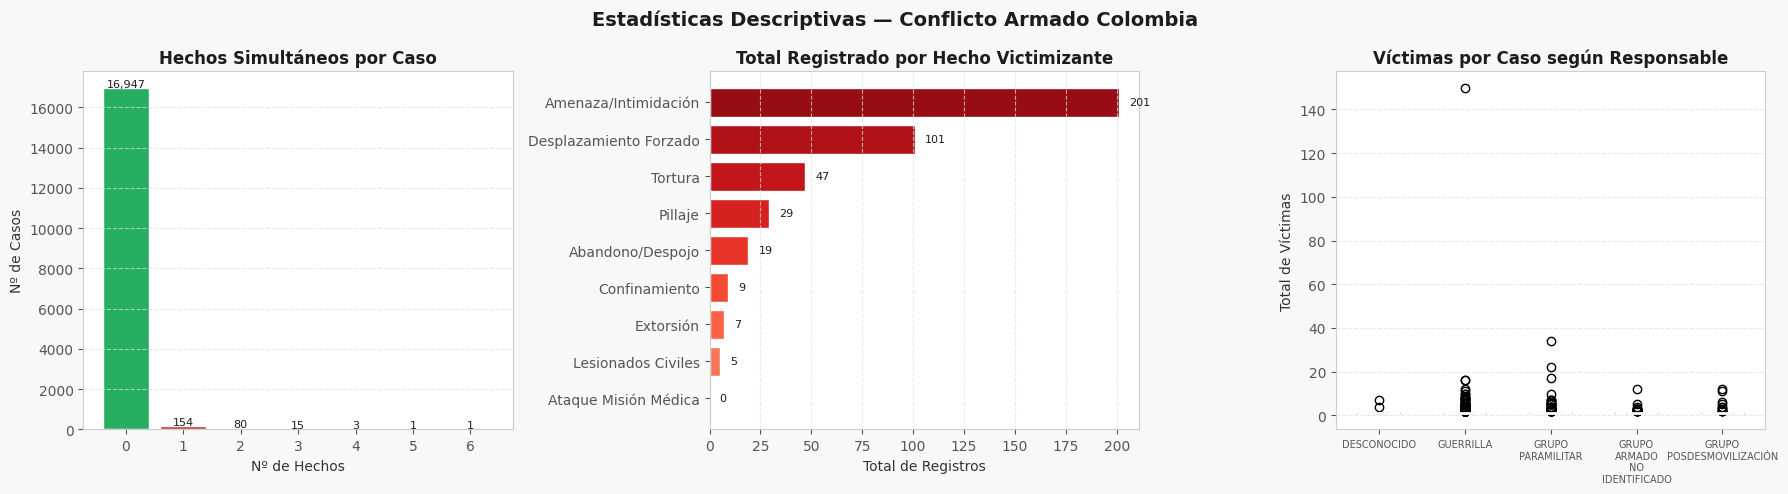

In [ ]:
# ── 3.6 Visualización resumen descriptivo ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Estadísticas Descriptivas — Conflicto Armado Colombia',
             fontsize=14, fontweight='bold')

# Gráfica 1: Total de hechos victimizantes
ax = axes[0]
colores = ['#27AE60' if i == 0 else RED for i in range(len(dist_hechos))]
ax.bar(dist_hechos.index, dist_hechos.values, color=colores, edgecolor='white')
ax.set_title('Hechos Simultáneos por Caso', fontweight='bold')
ax.set_xlabel('Nº de Hechos'); ax.set_ylabel('Nº de Casos')
for i, (x, y) in enumerate(zip(dist_hechos.index, dist_hechos.values)):
    ax.text(x, y + 50, f'{y:,}', ha='center', fontsize=8)
ax.grid(True, axis='y')

# Gráfica 2: Total registrado por hecho victimizante
ax = axes[1]
hechos_ord = resumen_hechos.sort_values('Total Registrados')
colores_h  = plt.cm.Reds(np.linspace(0.4, 0.9, len(hechos_ord)))
bars = ax.barh(hechos_ord.index, hechos_ord['Total Registrados'],
               color=colores_h, edgecolor='white')
ax.set_title('Total Registrado por Hecho Victimizante', fontweight='bold')
ax.set_xlabel('Total de Registros')
for bar, v in zip(bars, hechos_ord['Total Registrados']):
    ax.text(v + 5, bar.get_y() + bar.get_height()/2,
            f'{int(v):,}', va='center', fontsize=8)
ax.grid(True, axis='x')

# Gráfica 3: Distribución víctimas por caso (boxplot por responsable)
ax = axes[2]
top5 = df['Presunto Responsable'].value_counts().head(5).index
df_box = df[df['Presunto Responsable'].isin(top5)]
grupos = [df_box[df_box['Presunto Responsable'] == r]
          ['Total de Víctimas del Caso'].values for r in top5]
bp = ax.boxplot(grupos, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], PALETTE[:5]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticks(range(1, 6))
ax.set_xticklabels([r.replace(' ', '\n') for r in top5], fontsize=7)
ax.set_title('Víctimas por Caso según Responsable', fontweight='bold')
ax.set_ylabel('Total de Víctimas')
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

#SECCIÓN 4 — ANÁLISIS UNIVARIADO

El análisis univariado confirmó la alta concentración
de valores en 1 víctima por caso, con outliers extremos
de hasta 150 víctimas que generan la alta variabilidad
observada. La distribución de responsables muestra que
al excluir DESCONOCIDO, la Guerrilla domina ampliamente
con el 53% de los casos identificados.

La distribución temporal reveló que la década de los
2000s concentra el 73.7% de los casos con fecha válida
(4,444 de 6,025), siendo el año 2002 el de mayor
registro histórico. La estacionalidad mensual no muestra
un patrón claro aunque los primeros meses del año
tienden a registrar más eventos en años de alta
intensidad del conflicto.

Geográficamente, Antioquia lidera con 2,749 casos,
seguido de Meta (1,513) y Caquetá (1,263). A nivel
de región, Ariari Guayabero (1,466), Urabá (956) y
Magdalena Medio (800) concentran los mayores volúmenes,
coincidiendo con zonas históricas de disputa territorial.


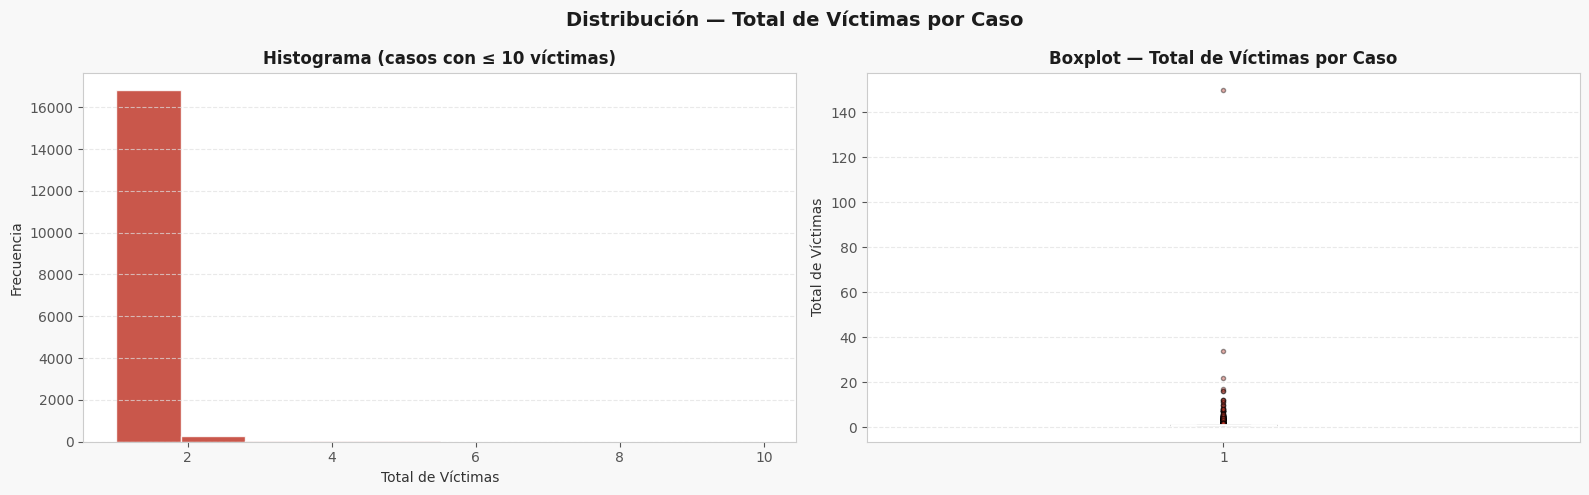

In [ ]:

# SECCIÓN 4: ANÁLISIS UNIVARIADO
# ============================================================

# ── 4.1 Distribución de víctimas por caso ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribución — Total de Víctimas por Caso',
             fontsize=14, fontweight='bold')

# Histograma (casos con <= 10 víctimas para legibilidad)
ax = axes[0]
vict_filt = df[df['Total de Víctimas del Caso'] <= 10]['Total de Víctimas del Caso']
ax.hist(vict_filt, bins=10, color=RED, edgecolor='white', alpha=0.85)
ax.set_title('Histograma (casos con ≤ 10 víctimas)', fontweight='bold')
ax.set_xlabel('Total de Víctimas'); ax.set_ylabel('Frecuencia')
ax.grid(True, axis='y')

# Boxplot general
ax = axes[1]
ax.boxplot(df['Total de Víctimas del Caso'], patch_artist=True,
           boxprops=dict(facecolor=RED, alpha=0.6),
           medianprops=dict(color='white', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor=RED,
                           markersize=3, alpha=0.4))
ax.set_title('Boxplot — Total de Víctimas por Caso', fontweight='bold')
ax.set_ylabel('Total de Víctimas')
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

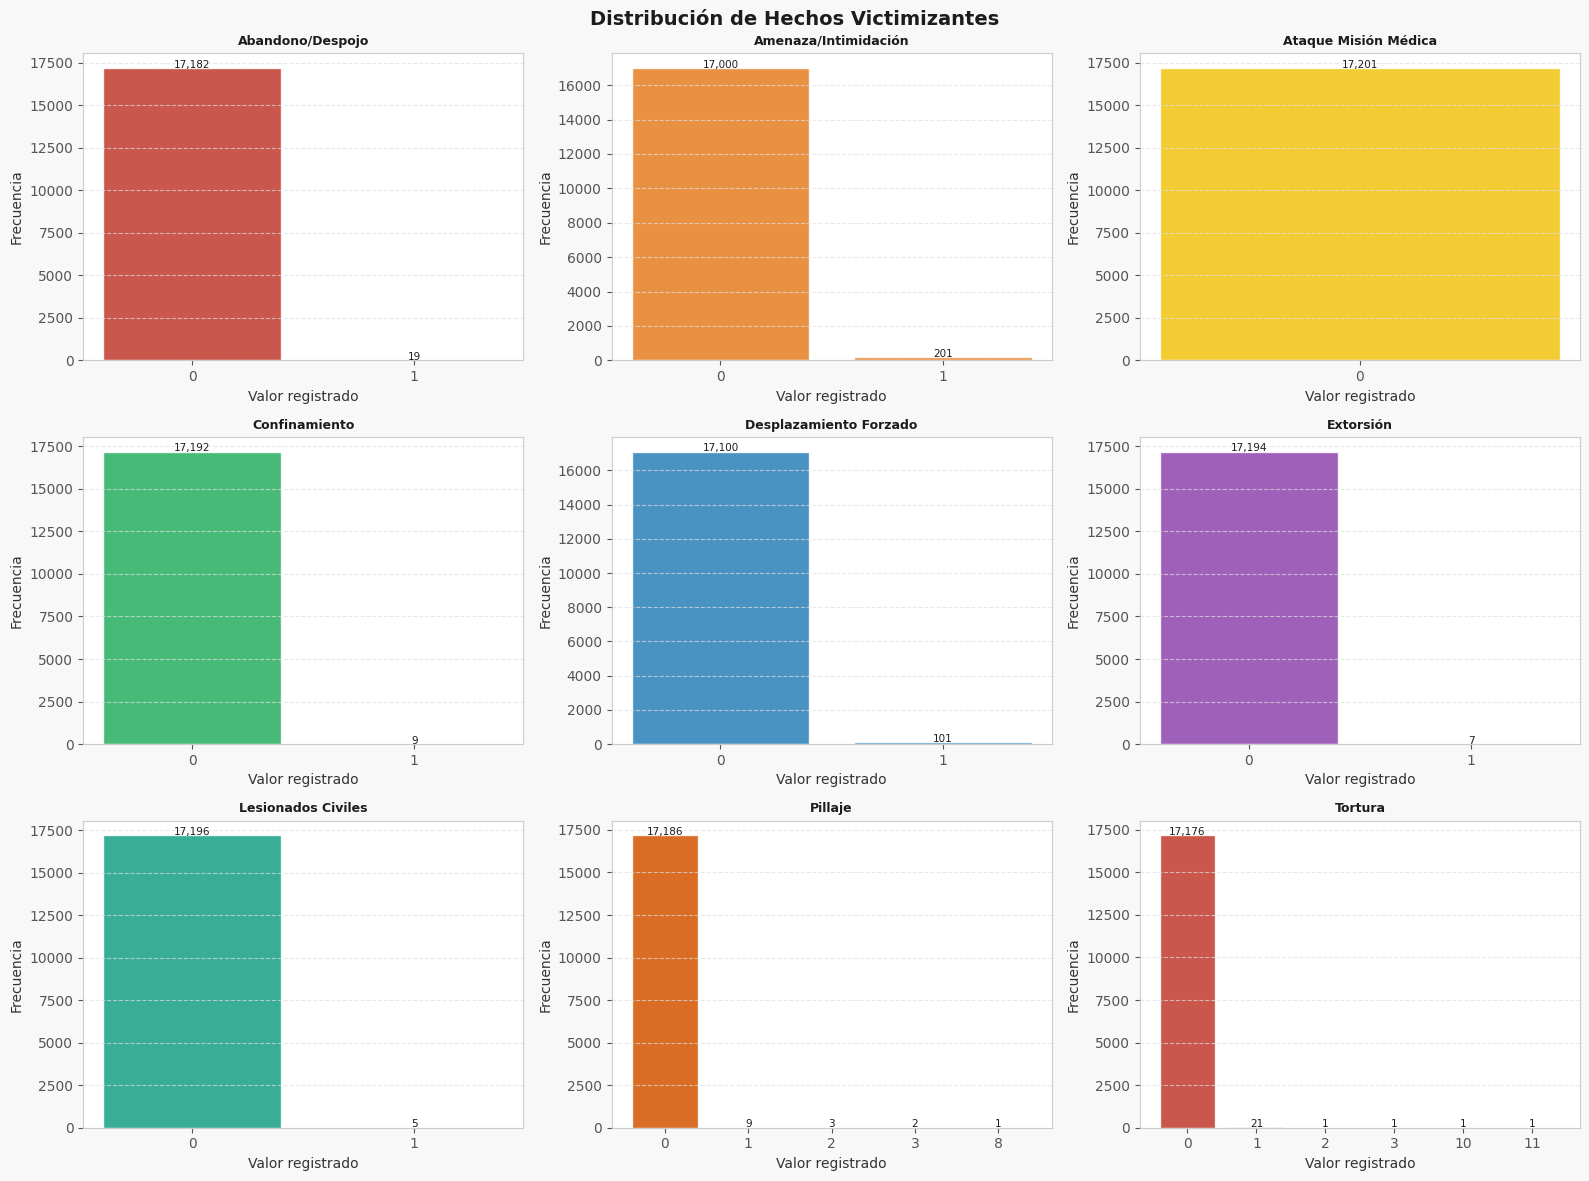

In [ ]:

# ── 4.2 Distribución de hechos victimizantes ───────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Distribución de Hechos Victimizantes',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (col, label) in enumerate(zip(HECHOS_COLS, HECHOS_LABELS)):
    ax = axes[i]
    conteo = df[col].value_counts().sort_index()
    ax.bar(conteo.index.astype(str), conteo.values,
           color=PALETTE[i % len(PALETTE)], edgecolor='white', alpha=0.85)
    ax.set_title(label, fontweight='bold', fontsize=9)
    ax.set_xlabel('Valor registrado')
    ax.set_ylabel('Frecuencia')
    for j, v in enumerate(conteo.values):
        ax.text(j, v + 20, f'{v:,}', ha='center', fontsize=7.5)
    ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

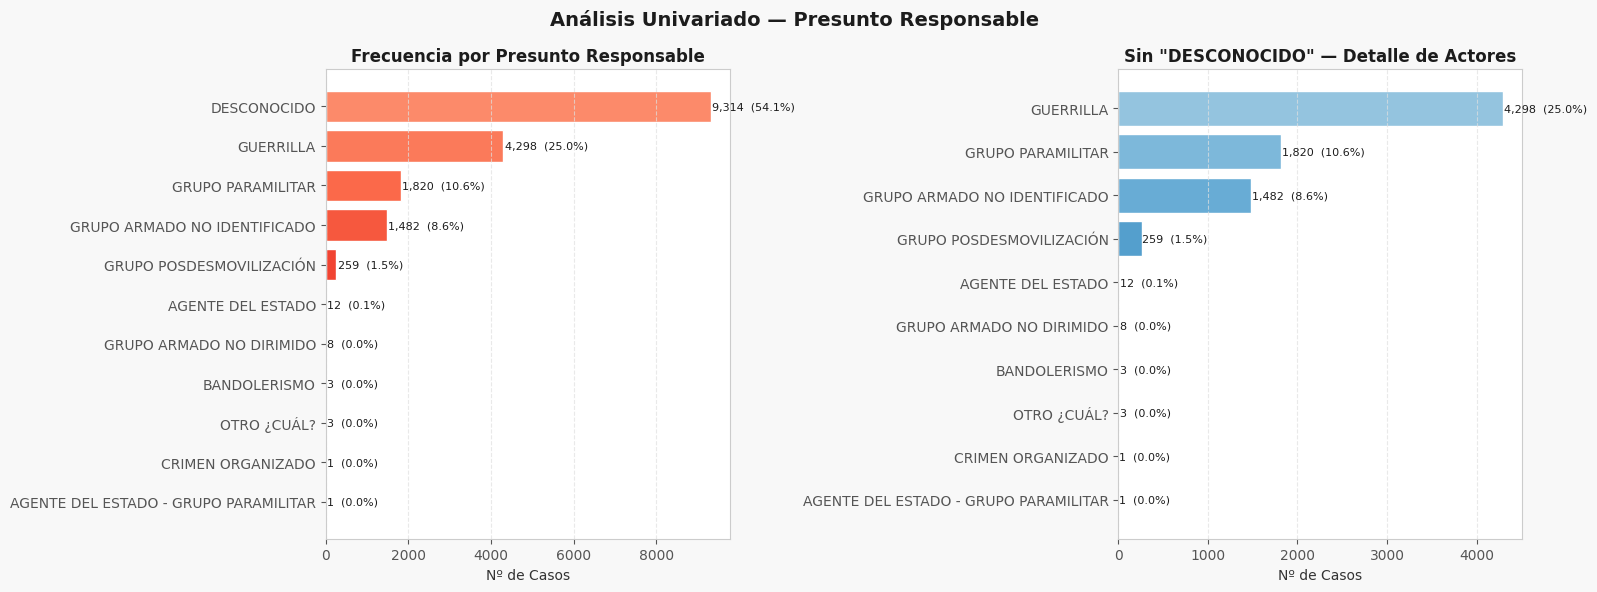

In [ ]:


# ── 4.3 Presunto Responsable ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis Univariado — Presunto Responsable',
             fontsize=14, fontweight='bold')

# Todos los valores
ax = axes[0]
resp = df['Presunto Responsable'].value_counts()
colores_r = plt.cm.Reds(np.linspace(0.4, 0.9, len(resp)))[::-1]
bars = ax.barh(resp.index[::-1], resp.values[::-1],
               color=colores_r, edgecolor='white')
ax.set_title('Frecuencia por Presunto Responsable', fontweight='bold')
ax.set_xlabel('Nº de Casos')
for bar, v in zip(bars, resp.values[::-1]):
    ax.text(v + 30, bar.get_y() + bar.get_height()/2,
            f'{v:,}  ({v/len(df)*100:.1f}%)', va='center', fontsize=8)
ax.grid(True, axis='x')

# Sin DESCONOCIDO para ver el detalle
ax = axes[1]
resp_sin_desc = resp[resp.index != 'DESCONOCIDO']
colores_r2 = plt.cm.Blues(np.linspace(0.4, 0.9, len(resp_sin_desc)))[::-1]
bars2 = ax.barh(resp_sin_desc.index[::-1], resp_sin_desc.values[::-1],
                color=colores_r2, edgecolor='white')
ax.set_title('Sin "DESCONOCIDO" — Detalle de Actores', fontweight='bold')
ax.set_xlabel('Nº de Casos')
for bar, v in zip(bars2, resp_sin_desc.values[::-1]):
    ax.text(v + 10, bar.get_y() + bar.get_height()/2,
            f'{v:,}  ({v/len(df)*100:.1f}%)', va='center', fontsize=8)
ax.grid(True, axis='x')

plt.tight_layout()
plt.show()

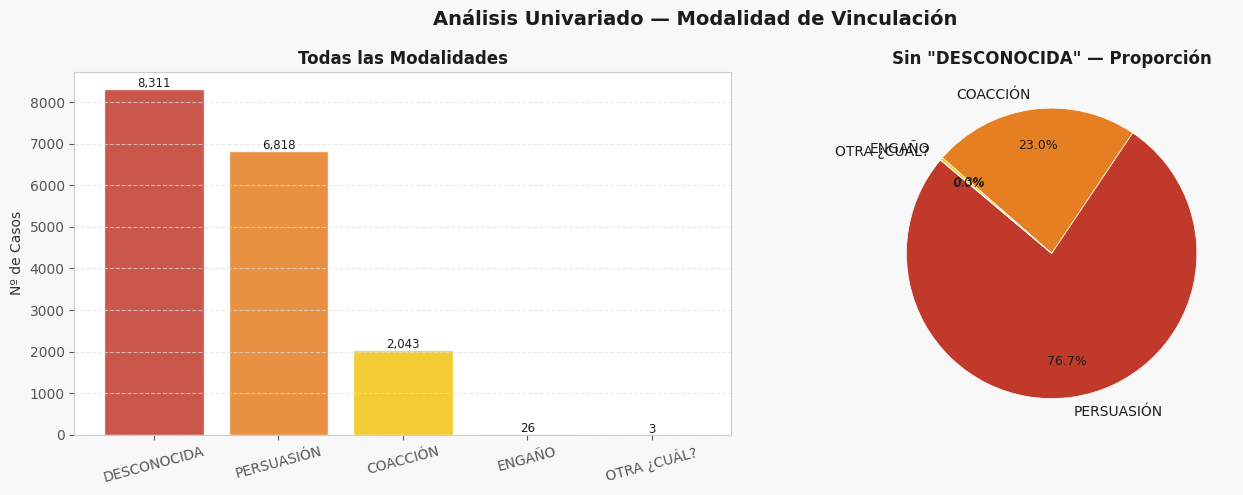

In [ ]:

# ── 4.4 Modalidad ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis Univariado — Modalidad de Vinculación',
             fontsize=14, fontweight='bold')

ax = axes[0]
mod = df['Modalidad'].value_counts()
ax.bar(mod.index, mod.values,
       color=PALETTE[:len(mod)], edgecolor='white', alpha=0.85)
ax.set_title('Todas las Modalidades', fontweight='bold')
ax.set_ylabel('Nº de Casos')
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(mod.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=8.5)
ax.grid(True, axis='y')

# Sin DESCONOCIDA
ax = axes[1]
mod_sin = mod[mod.index != 'DESCONOCIDA']
wedges, texts, autotexts = ax.pie(
    mod_sin.values, labels=mod_sin.index,
    autopct='%1.1f%%', colors=PALETTE[:len(mod_sin)],
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(linewidth=0.5, edgecolor='white'))
for at in autotexts: at.set_fontsize(9)
ax.set_title('Sin "DESCONOCIDA" — Proporción', fontweight='bold')

plt.tight_layout()
plt.show()

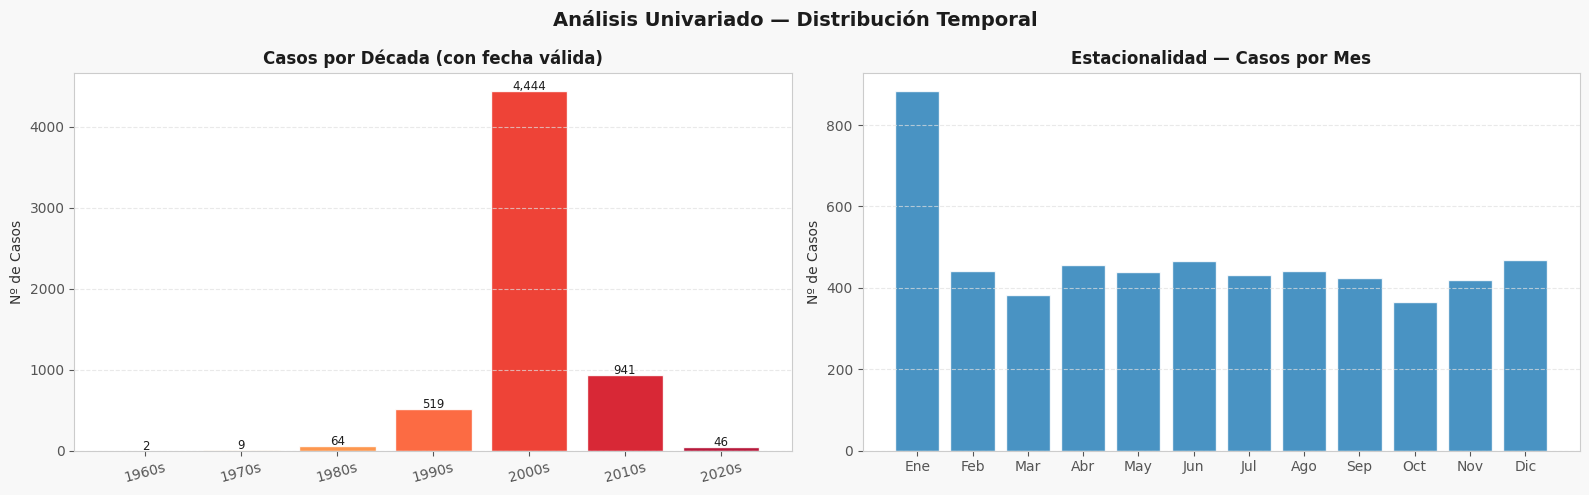

In [ ]:




# ── 4.5 Distribución temporal (solo registros con fecha) ──

# Recrear df_temporal con la columna Década incluida
df_temporal = df[df['Año_valido'].notna()].copy()
df_temporal['Década'] = (df_temporal['Año_valido']
                         .apply(lambda x: f"{int(x)//10*10}s"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Análisis Univariado — Distribución Temporal',
             fontsize=14, fontweight='bold')

# Por década
ax = axes[0]
decadas = df_temporal['Década'].value_counts().sort_index()
colores_d = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(decadas)))
ax.bar(decadas.index, decadas.values,
       color=colores_d, edgecolor='white', alpha=0.9)
ax.set_title('Casos por Década (con fecha válida)', fontweight='bold')
ax.set_ylabel('Nº de Casos')
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(decadas.values):
    ax.text(i, v + 10, f'{v:,}', ha='center', fontsize=8.5)
ax.grid(True, axis='y')

# Por mes
ax = axes[1]
meses_nombre = ['Ene','Feb','Mar','Abr','May','Jun',
                'Jul','Ago','Sep','Oct','Nov','Dic']
df_mes = df_temporal[df_temporal['Mes_valido'].notna()]
estac = df_mes['Mes_valido'].value_counts().sort_index()
ax.bar(range(1, 13),
       [estac.get(m, 0) for m in range(1, 13)],
       color=BLUE, edgecolor='white', alpha=0.85)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nombre)
ax.set_title('Estacionalidad — Casos por Mes', fontweight='bold')
ax.set_ylabel('Nº de Casos')
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

📊 Registros en el período 2000-2010: 4,678
   Representan el 77.6% de los casos con fecha válida
   Total víctimas en el período: 5,086


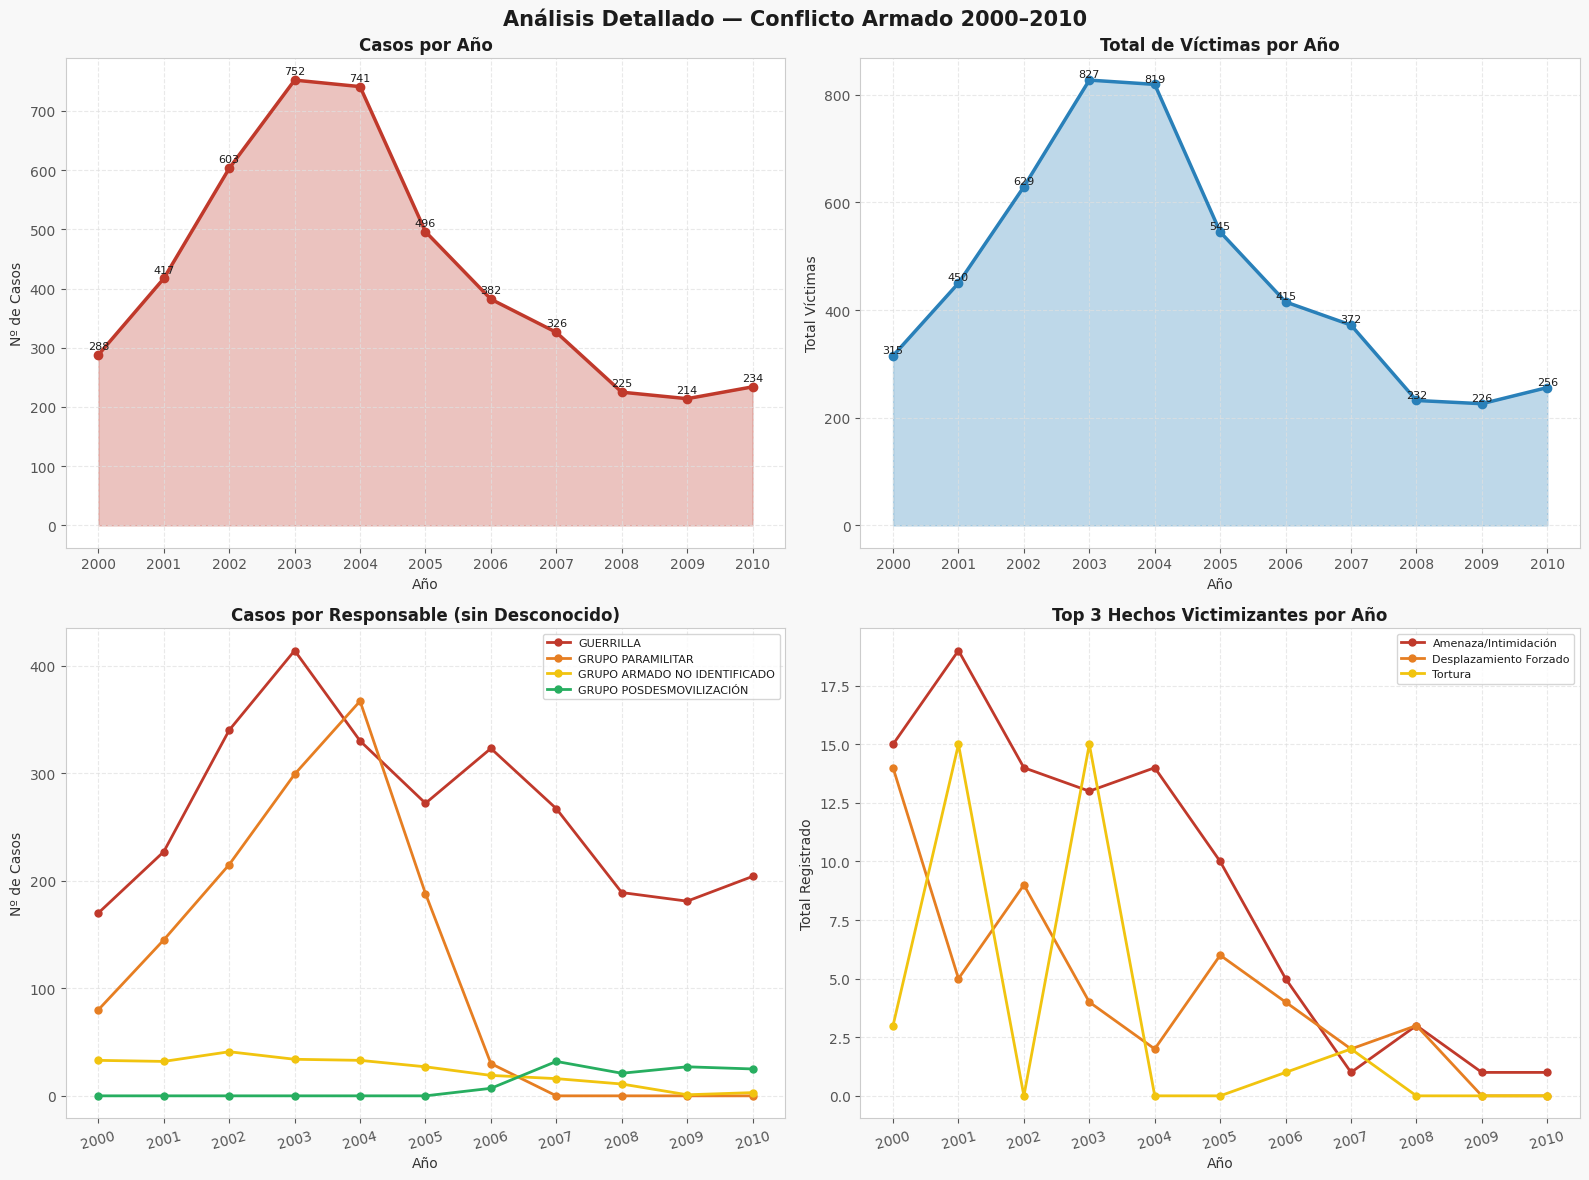

In [ ]:
# ============================================================
# ANÁLISIS DETALLADO — PERÍODO 2000 A 2010
# ============================================================

# ── Filtrar el período de interés ─────────────────────────
df_2000_2010 = df_temporal[
    (df_temporal['Año_valido'] >= 2000) &
    (df_temporal['Año_valido'] <= 2010)
].copy()

print(f"📊 Registros en el período 2000-2010: {len(df_2000_2010):,}")
print(f"   Representan el {len(df_2000_2010)/len(df_temporal)*100:.1f}% de los casos con fecha válida")
print(f"   Total víctimas en el período: {df_2000_2010['Total de Víctimas del Caso'].sum():,}")

# ── Gráfica 1: Casos y víctimas por año ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis Detallado — Conflicto Armado 2000–2010',
             fontsize=15, fontweight='bold')

# Casos por año
ax = axes[0, 0]
casos_año = df_2000_2010.groupby('Año_valido').size()
ax.fill_between(casos_año.index, casos_año.values, alpha=0.3, color=RED)
ax.plot(casos_año.index, casos_año.values, color=RED,
        linewidth=2.5, marker='o', markersize=6)
ax.set_title('Casos por Año', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Nº de Casos')
ax.set_xticks(range(2000, 2011))
for x, y in zip(casos_año.index, casos_año.values):
    ax.text(x, y + 10, str(y), ha='center', fontsize=8)
ax.grid(True)

# Víctimas por año
ax = axes[0, 1]
vic_año = df_2000_2010.groupby('Año_valido')['Total de Víctimas del Caso'].sum()
ax.fill_between(vic_año.index, vic_año.values, alpha=0.3, color=BLUE)
ax.plot(vic_año.index, vic_año.values, color=BLUE,
        linewidth=2.5, marker='o', markersize=6)
ax.set_title('Total de Víctimas por Año', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Total Víctimas')
ax.set_xticks(range(2000, 2011))
for x, y in zip(vic_año.index, vic_año.values):
    ax.text(x, y + 5, str(y), ha='center', fontsize=8)
ax.grid(True)
# Presunto responsable por año
ax = axes[1, 0]
top4_resp = (df_2000_2010[df_2000_2010['Presunto Responsable'] != 'DESCONOCIDO']
             ['Presunto Responsable'].value_counts().head(4).index)
for i, r in enumerate(top4_resp):
    data = (df_2000_2010[df_2000_2010['Presunto Responsable'] == r]
            .groupby('Año_valido').size()
            .reindex(range(2000, 2011), fill_value=0))
    ax.plot(data.index, data.values, label=r,
            color=PALETTE[i], linewidth=2, marker='o', markersize=5)
ax.set_title('Casos por Responsable (sin Desconocido)', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Nº de Casos')
ax.set_xticks(range(2000, 2011))
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=8)
ax.grid(True)

# Hechos victimizantes por año
ax = axes[1, 1]
hechos_año = df_2000_2010.groupby('Año_valido')[HECHOS_COLS].sum()
hechos_top3 = hechos_año[['Amenaza o Intimidación',
                           'Desplazamiento Forzado',
                           'Tortura']]
for i, col in enumerate(hechos_top3.columns):
    ax.plot(hechos_top3.index, hechos_top3[col],
            label=HECHOS_LABELS[HECHOS_COLS.index(col)],
            color=PALETTE[i], linewidth=2, marker='o', markersize=5)
ax.set_title('Top 3 Hechos Victimizantes por Año', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Total Registrado')
ax.set_xticks(range(2000, 2011))
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.show()


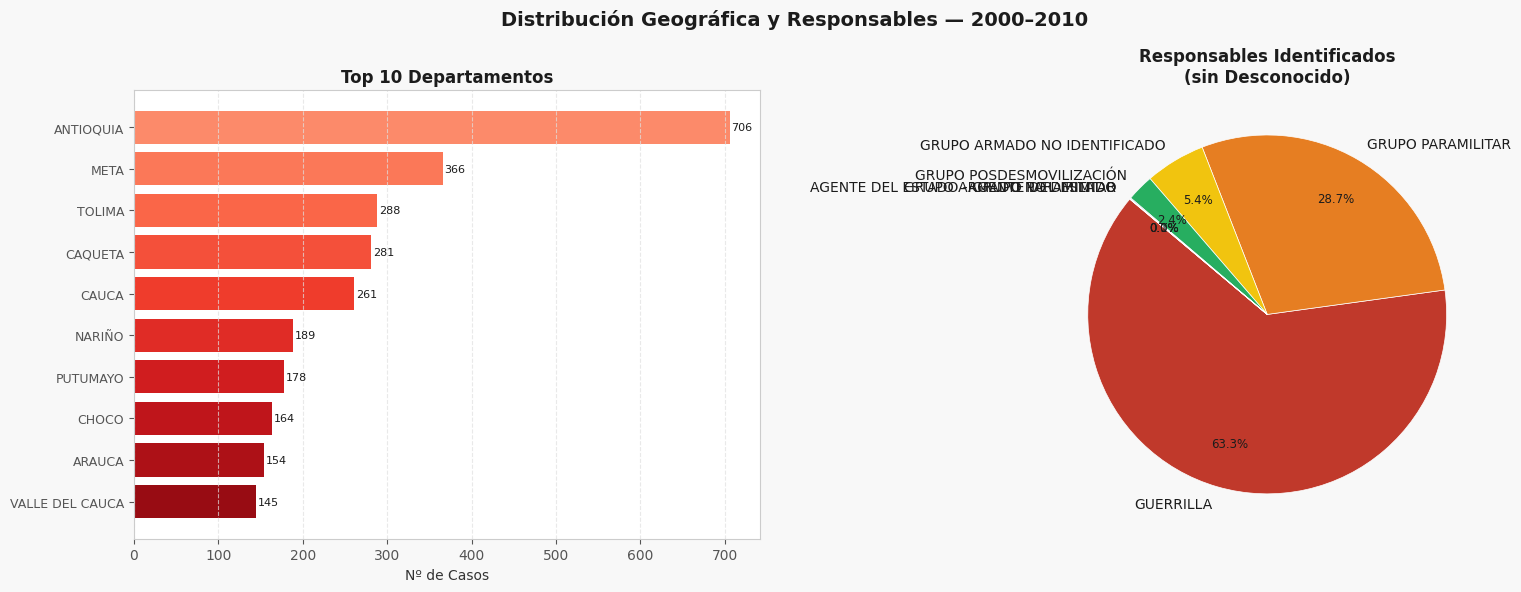


📋 RESUMEN ESTADÍSTICO — 2000 A 2010
  Año con más casos:      2003 (752 casos)
  Año con menos casos:    2009 (214 casos)
  Año con más víctimas:   2003 (827 víctimas)
  Dpto. más afectado:     ANTIOQUIA (706 casos)
  Principal responsable:  GUERRILLA (2,917 casos)
  Hecho más frecuente:    Amenaza/Intimidación


In [ ]:


# ── Gráfica 2: Geografía y responsables ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribución Geográfica y Responsables — 2000–2010',
             fontsize=14, fontweight='bold')
# Top 10 departamentos en el período
ax = axes[0]
top_dep = (df_2000_2010[df_2000_2010['Departamento'] != 'SIN INFORMACION']
           ['Departamento'].value_counts().head(10))
colores_dep = plt.cm.Reds(np.linspace(0.4, 0.9, 10))[::-1]
bars = ax.barh(range(10), top_dep.values[::-1], color=colores_dep)
ax.set_yticks(range(10))
ax.set_yticklabels(top_dep.index[::-1], fontsize=9)
ax.set_title('Top 10 Departamentos', fontweight='bold')
ax.set_xlabel('Nº de Casos')
for bar, v in zip(bars, top_dep.values[::-1]):
    ax.text(v + 2, bar.get_y() + bar.get_height()/2,
            f'{v:,}', va='center', fontsize=8)
ax.grid(True, axis='x')

# Responsables en el período (sin DESCONOCIDO)
ax = axes[1]
resp_per = (df_2000_2010[df_2000_2010['Presunto Responsable'] != 'DESCONOCIDO']
            ['Presunto Responsable'].value_counts())
wedges, texts, autotexts = ax.pie(
    resp_per.values, labels=resp_per.index,
    autopct='%1.1f%%', colors=PALETTE[:len(resp_per)],
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(linewidth=0.5, edgecolor='white'))
for at in autotexts: at.set_fontsize(8.5)
ax.set_title('Responsables Identificados\n(sin Desconocido)', fontweight='bold')

plt.tight_layout()
plt.show()

# ── Resumen estadístico del período ───────────────────────
print("\n" + "=" * 55)
print("📋 RESUMEN ESTADÍSTICO — 2000 A 2010")
print("=" * 55)
print(f"  Año con más casos:      {int(casos_año.idxmax())} ({casos_año.max():,} casos)")
print(f"  Año con menos casos:    {int(casos_año.idxmin())} ({casos_año.min():,} casos)")
print(f"  Año con más víctimas:   {int(vic_año.idxmax())} ({vic_año.max():,} víctimas)")
print(f"  Dpto. más afectado:     {top_dep.index[0]} ({top_dep.iloc[0]:,} casos)")
print(f"  Principal responsable:  {resp_per.index[0]} ({resp_per.iloc[0]:,} casos)")
print(f"  Hecho más frecuente:    Amenaza/Intimidación")
print("=" * 55)




#SECCIÓN 5 — ANÁLISIS BIVARIADO Y MULTIVARIADO

La correlación más alta entre hechos victimizantes
se da entre Desplazamiento Forzado y Amenaza/
Intimidación (r=0.52), sugiriendo que la intimidación
es un mecanismo previo y sistemático al desplazamiento.
En general las correlaciones entre hechos son bajas,
indicando que cada uno tiende a ocurrir de forma
independiente.

El cruce Responsable × Modalidad reveló diferencias
estratégicas entre actores: la Guerrilla usa Coacción
(352 casos) y Persuasión (242) casi en igual proporción,
mientras los Paramilitares dependen más de la Persuasión
(231) que de la Coacción (108), reflejando estrategias
diferenciadas de reclutamiento.

La Guerrilla acumula 4,967 víctimas identificadas,
más del doble que los Paramilitares (2,039). El cruce
por departamento confirma que la Guerrilla domina en
prácticamente todos los territorios, con especial
presencia en Antioquia, Meta, Caquetá, Cauca y Tolima.

La prueba Chi-cuadrado confirmó que el tipo de
responsable NO es independiente de la modalidad
ni del departamento (p<0.05), es decir, cada actor
armado opera de forma diferenciada según el territorio
y el método utilizado.

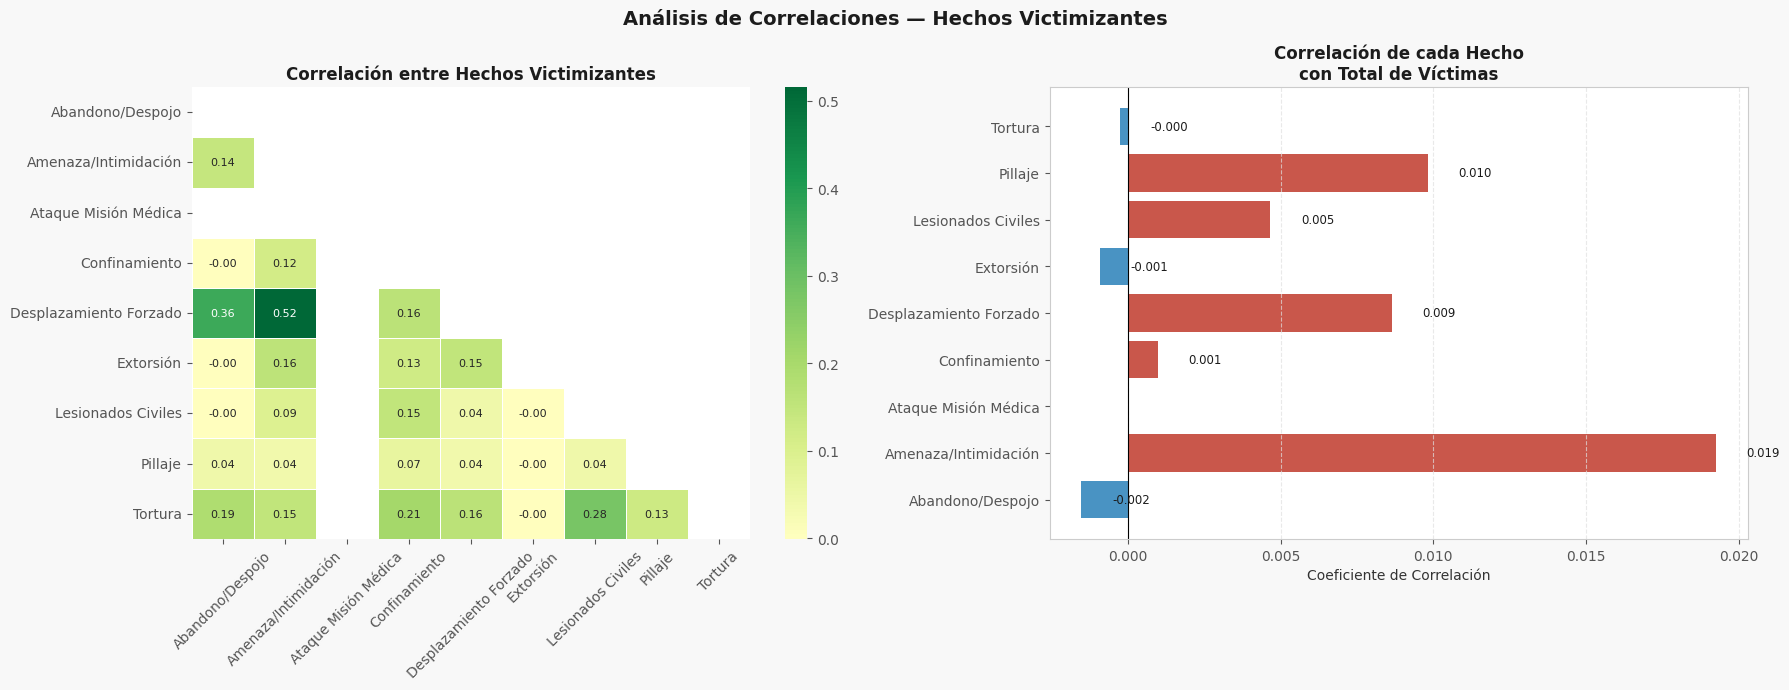

In [ ]:
# ============================================================
# SECCIÓN 5: ANÁLISIS BIVARIADO Y MULTIVARIADO
# ============================================================

# ── 5.1 Matriz de correlación — hechos victimizantes ──────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Análisis de Correlaciones — Hechos Victimizantes',
             fontsize=14, fontweight='bold')

# Correlación entre hechos victimizantes
ax = axes[0]
corr_hechos = df[HECHOS_COLS].corr()
mask = np.triu(np.ones_like(corr_hechos, dtype=bool))
sns.heatmap(corr_hechos, ax=ax, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            xticklabels=HECHOS_LABELS, yticklabels=HECHOS_LABELS,
            annot_kws={'size': 8})
ax.set_title('Correlación entre Hechos Victimizantes', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

# Correlación con total de víctimas
ax = axes[1]
corr_vic = df[HECHOS_COLS + ['Total de Víctimas del Caso']].corr()[
    'Total de Víctimas del Caso'].drop('Total de Víctimas del Caso')
colores_corr = [RED if v > 0 else BLUE for v in corr_vic.values]
bars = ax.barh(HECHOS_LABELS, corr_vic.values, color=colores_corr, alpha=0.85)
ax.set_title('Correlación de cada Hecho\ncon Total de Víctimas', fontweight='bold')
ax.set_xlabel('Coeficiente de Correlación')
ax.axvline(0, color='black', linewidth=0.8)
for bar, v in zip(bars, corr_vic.values):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=8.5)
ax.grid(True, axis='x')

plt.tight_layout()
plt.show()

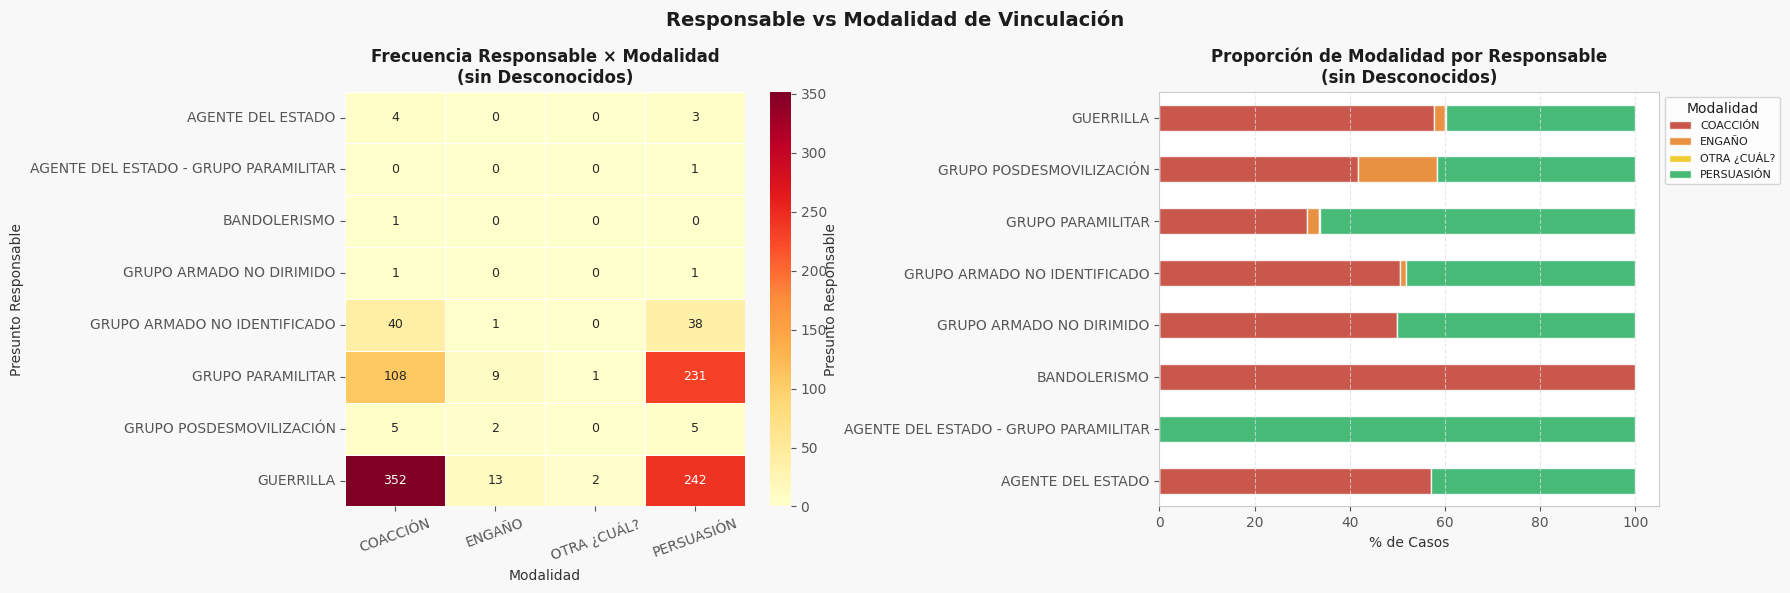

In [ ]:

# ── 5.2 Responsable vs Modalidad ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Responsable vs Modalidad de Vinculación',
             fontsize=14, fontweight='bold')

# Heatmap de frecuencias
ax = axes[0]
df_filt = df[
    (df['Presunto Responsable'] != 'DESCONOCIDO') &
    (df['Modalidad'] != 'DESCONOCIDA')
]
pivot_resp_mod = pd.crosstab(df_filt['Presunto Responsable'],
                              df_filt['Modalidad'])
sns.heatmap(pivot_resp_mod, ax=ax, annot=True, fmt='d',
            cmap='YlOrRd', linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Frecuencia Responsable × Modalidad\n(sin Desconocidos)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

# Barras apiladas
ax = axes[1]
pivot_norm = pivot_resp_mod.div(pivot_resp_mod.sum(axis=1), axis=0) * 100
pivot_norm.plot(kind='barh', stacked=True, ax=ax,
                color=PALETTE[:len(pivot_norm.columns)],
                edgecolor='white', alpha=0.85)
ax.set_title('Proporción de Modalidad por Responsable\n(sin Desconocidos)',
             fontweight='bold')
ax.set_xlabel('% de Casos')
ax.legend(title='Modalidad', bbox_to_anchor=(1, 1), fontsize=8)
ax.grid(True, axis='x')

plt.tight_layout()
plt.show()


# RESPONSABLE VS MODALIDAD:
# La Guerrilla es el actor con mayor volumen de casos identificados,
# usando Coacción (352) y Persuasión (242) casi en igual proporción.
# Los Paramilitares en cambio dependen mucho más de la Persuasión (231)
# que de la Coacción (108), lo que refleja estrategias distintas
# de reclutamiento entre ambos grupos.

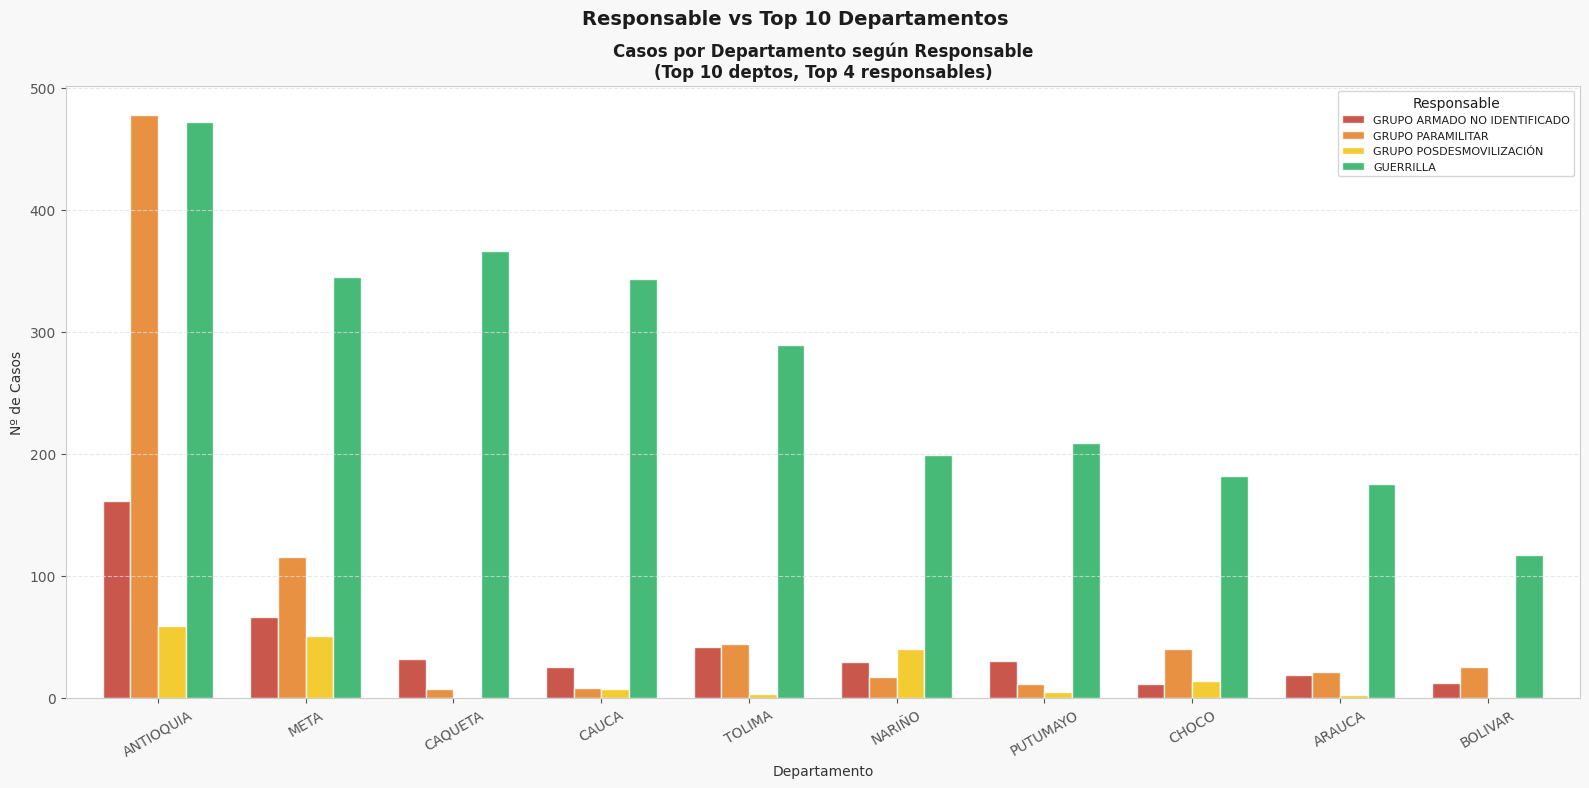

In [ ]:


# ── 5.3 Responsable vs Departamento ───────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle('Responsable vs Top 10 Departamentos',
             fontsize=14, fontweight='bold')

top10_dep = (df[df['Departamento'] != 'SIN INFORMACION']
             ['Departamento'].value_counts().head(10).index)
top4_resp  = (df[df['Presunto Responsable'] != 'DESCONOCIDO']
              ['Presunto Responsable'].value_counts().head(4).index)

df_rd = df[
    df['Departamento'].isin(top10_dep) &
    df['Presunto Responsable'].isin(top4_resp)
]
pivot_rd = pd.crosstab(df_rd['Departamento'],
                        df_rd['Presunto Responsable'])
pivot_rd = pivot_rd.loc[top10_dep]

pivot_rd.plot(kind='bar', ax=ax, color=PALETTE[:4],
              edgecolor='white', alpha=0.85, width=0.75)
ax.set_title('Casos por Departamento según Responsable\n(Top 10 deptos, Top 4 responsables)',
             fontweight='bold')
ax.set_xlabel('Departamento')
ax.set_ylabel('Nº de Casos')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Responsable', fontsize=8)
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

# RESPONSABLE VS DEPARTAMENTO:
# La Guerrilla domina en prácticamente todos los departamentos,
# siendo especialmente fuerte en Antioquia, Meta, Caquetá,
# Cauca y Tolima. Los Paramilitares tienen mayor presencia
# relativa en Antioquia y Meta. Caquetá y Cauca son
# territorios casi exclusivamente guerrilleros.


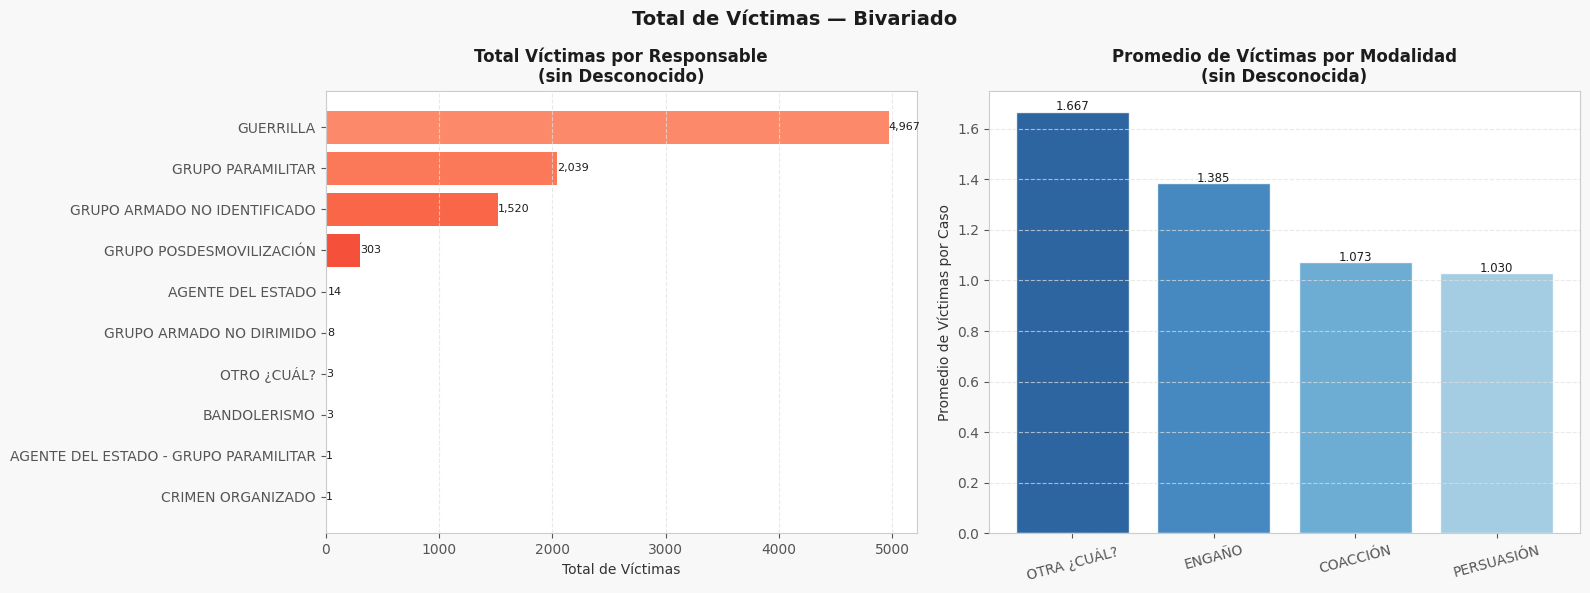


🧪 PRUEBA CHI-CUADRADO — Independencia entre variables

  Presunto Responsable × Modalidad
    Chi2=78.99  |  p-valor=0.0000  |  gl=21
    Conclusión: ✅ Dependientes (α=0.05)

  Presunto Responsable × Departamento
    Chi2=1713.26  |  p-valor=0.0000  |  gl=288
    Conclusión: ✅ Dependientes (α=0.05)

  Modalidad × Tipo de Vinculación
    Chi2=11460.62  |  p-valor=0.0000  |  gl=16
    Conclusión: ✅ Dependientes (α=0.05)


In [ ]:


# ── 5.4 Víctimas por Responsable y Modalidad ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Total de Víctimas — Bivariado',
             fontsize=14, fontweight='bold')

# Promedio de víctimas por responsable
ax = axes[0]
vic_resp = (df[df['Presunto Responsable'] != 'DESCONOCIDO']
            .groupby('Presunto Responsable')['Total de Víctimas del Caso']
            .agg(['mean', 'sum', 'count'])
            .sort_values('sum', ascending=False))
colores_vr = plt.cm.Reds(np.linspace(0.4, 0.9, len(vic_resp)))[::-1]
bars = ax.barh(vic_resp.index[::-1], vic_resp['sum'].values[::-1],
               color=colores_vr)
ax.set_title('Total Víctimas por Responsable\n(sin Desconocido)',
             fontweight='bold')
ax.set_xlabel('Total de Víctimas')
for bar, v in zip(bars, vic_resp['sum'].values[::-1]):
    ax.text(v + 2, bar.get_y() + bar.get_height()/2,
            f'{int(v):,}', va='center', fontsize=8)
ax.grid(True, axis='x')

# Promedio de víctimas por modalidad
ax = axes[1]
vic_mod = (df[df['Modalidad'] != 'DESCONOCIDA']
           .groupby('Modalidad')['Total de Víctimas del Caso']
           .agg(['mean', 'sum', 'count'])
           .sort_values('mean', ascending=False))
colores_vm = plt.cm.Blues(np.linspace(0.4, 0.9, len(vic_mod)))[::-1]
bars2 = ax.bar(vic_mod.index, vic_mod['mean'].values,
               color=colores_vm, edgecolor='white', alpha=0.85)
ax.set_title('Promedio de Víctimas por Modalidad\n(sin Desconocida)',
             fontweight='bold')
ax.set_ylabel('Promedio de Víctimas por Caso')
ax.tick_params(axis='x', rotation=15)
for bar, v in zip(bars2, vic_mod['mean'].values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
            f'{v:.3f}', ha='center', fontsize=8.5)
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

# ── 5.5 Prueba Chi-cuadrado — Responsable vs Modalidad ────
print("\n" + "=" * 55)
print("🧪 PRUEBA CHI-CUADRADO — Independencia entre variables")
print("=" * 55)

pares = [
    ('Presunto Responsable', 'Modalidad'),
    ('Presunto Responsable', 'Departamento'),
    ('Modalidad',            'Tipo de Vinculación'),
]

for var1, var2 in pares:
    df_chi = df[
        (df[var1] != 'DESCONOCIDO') & (df[var1] != 'SIN INFORMACION') &
        (df[var2] != 'DESCONOCIDA') & (df[var2] != 'SIN INFORMACION')
    ]
    tabla = pd.crosstab(df_chi[var1], df_chi[var2])
    chi2, p, dof, _ = chi2_contingency(tabla)
    resultado = "✅ Dependientes" if p < 0.05 else "❌ Independientes"
    print(f"\n  {var1} × {var2}")
    print(f"    Chi2={chi2:.2f}  |  p-valor={p:.4f}  |  gl={dof}")
    print(f"    Conclusión: {resultado} (α=0.05)")

#SECCIÓN 6 — ANÁLISIS TEMPORAL

Nota: Este análisis se realizó únicamente sobre los
6,025 registros con fecha válida (35% del total).

La media móvil de 3 años revela una escalada sostenida
del conflicto entre 1990 y 2002, con el pico máximo
en 2002-2003 (más de 700 casos en un solo año).
A partir de 2003 se observa un descenso gradual,
posiblemente asociado a la política de Seguridad
Democrática del gobierno de ese período.

La Guerrilla mantiene presencia constante durante
todo el período analizado. Los Paramilitares muestran
un pico marcado entre 1999-2003 y desaparecen
progresivamente tras su desmovilización en 2006.

El heatmap año × mes no evidencia una estacionalidad
mensual clara, aunque en los años de mayor intensidad
(2001-2005) los primeros meses del año concentran
mayor actividad. El hecho más frecuente a lo largo
del tiempo es Amenaza/Intimidación, seguido de
Desplazamiento Forzado y Tortura.

Análisis 2000-2010:
Este período concentra el 73.7% de los casos con
fecha válida. Antioquia, Meta y Caquetá lideran
también en este subperíodo. La Guerrilla domina
como responsable identificado en todos los años,
con los Paramilitares como segundo actor hasta 2006.

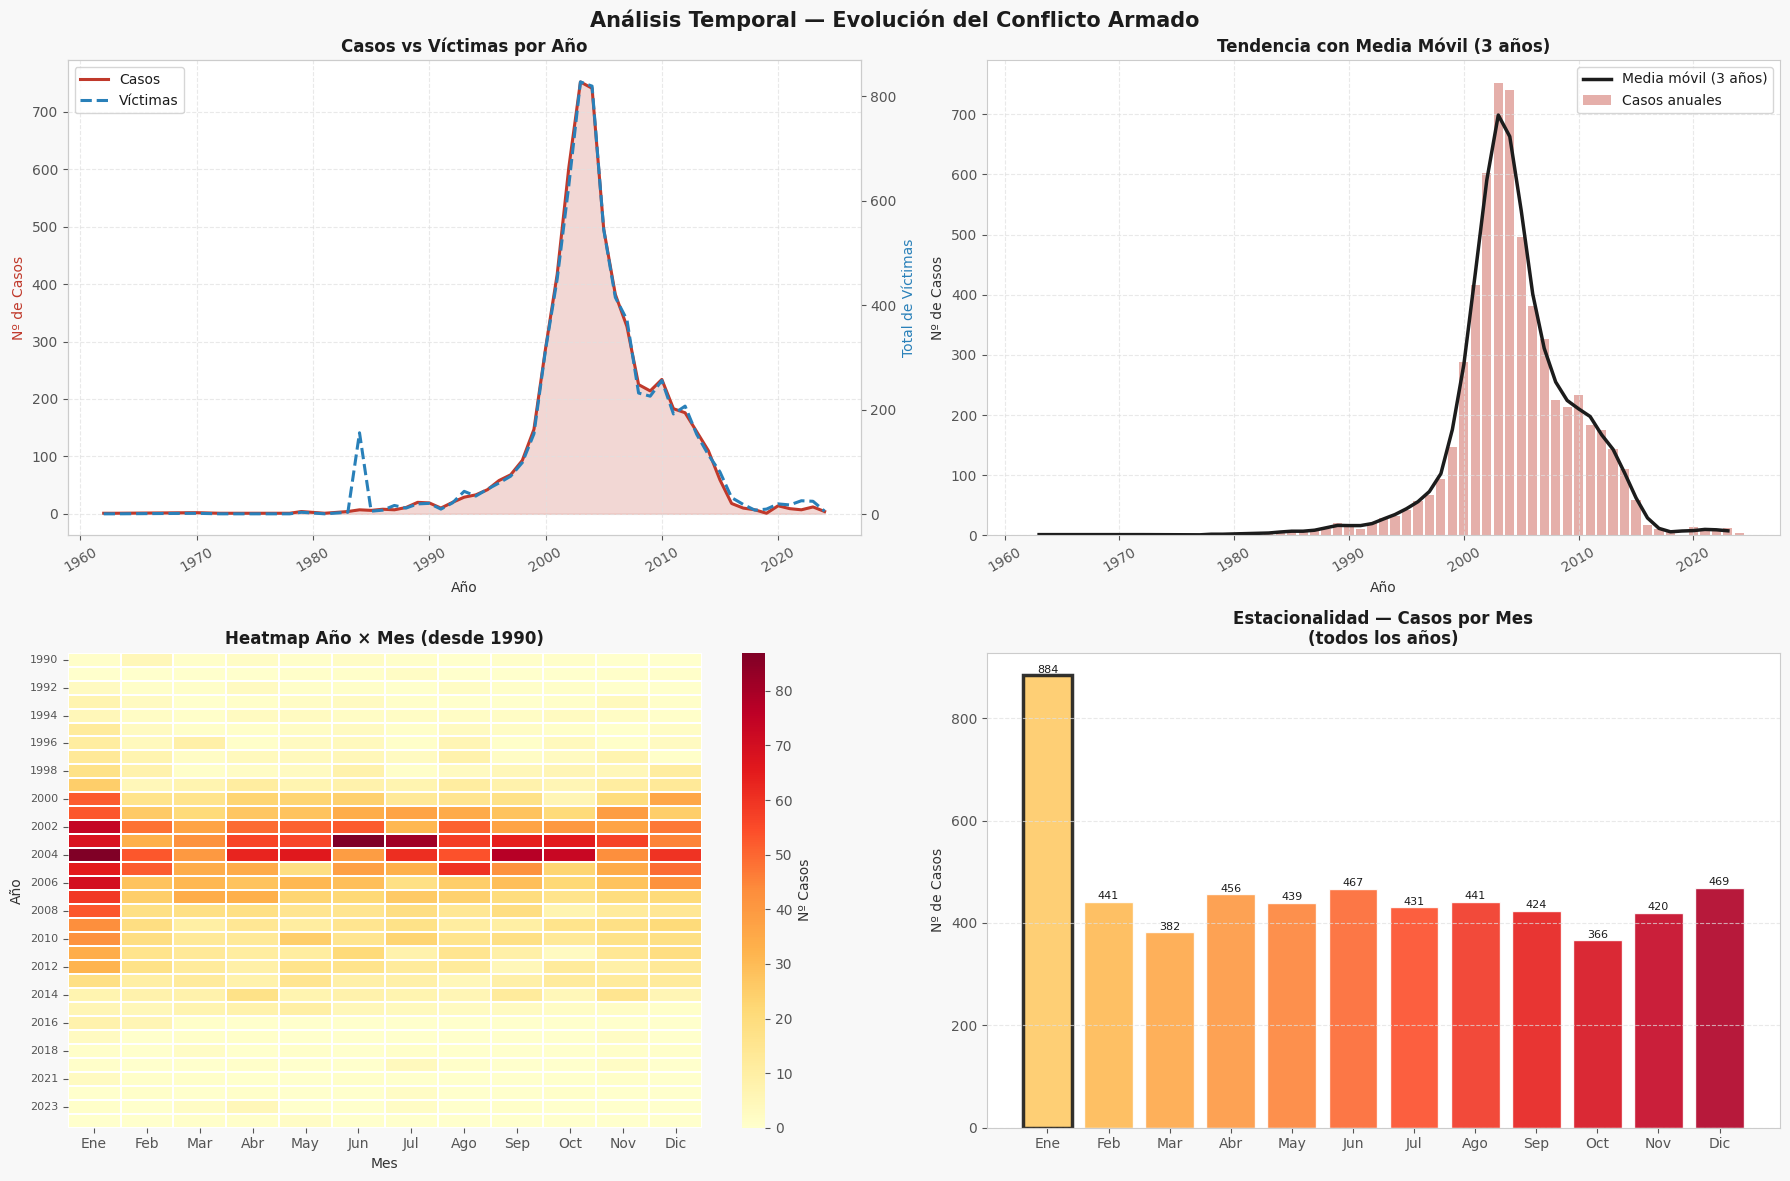

In [ ]:
# ============================================================
# SECCIÓN 6: ANÁLISIS TEMPORAL
# ============================================================
# ── Colores faltantes ──────────────────────────────────────
DARK  = '#1C1C1C'
MID   = '#4A4A4A'
LIGHT = '#F8F8F8'
# ── 6.1 Evolución general del conflicto ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Análisis Temporal — Evolución del Conflicto Armado',
             fontsize=15, fontweight='bold')

# Casos y víctimas por año
ax = axes[0, 0]
casos_año  = df_temporal.groupby('Año_valido').size()
vic_año    = df_temporal.groupby('Año_valido')['Total de Víctimas del Caso'].sum()

ax2 = ax.twinx()
ax.fill_between(casos_año.index, casos_año.values,
                alpha=0.2, color=RED)
ax.plot(casos_año.index, casos_año.values,
        color=RED, linewidth=2.2, label='Casos')
ax2.plot(vic_año.index, vic_año.values,
         color=BLUE, linewidth=2.2, linestyle='--', label='Víctimas')
ax.set_title('Casos vs Víctimas por Año', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Nº de Casos', color=RED)
ax2.set_ylabel('Total de Víctimas', color=BLUE)
ax.tick_params(axis='x', rotation=30)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax.grid(True)

# Tendencia con media móvil
ax = axes[0, 1]
casos_serie = casos_año.copy()
media_movil = casos_serie.rolling(window=3, center=True).mean()
ax.bar(casos_serie.index, casos_serie.values,
       color=RED, alpha=0.4, label='Casos anuales')
ax.plot(media_movil.index, media_movil.values,
        color=DARK, linewidth=2.5, label='Media móvil (3 años)')
ax.set_title('Tendencia con Media Móvil (3 años)', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Nº de Casos')
ax.tick_params(axis='x', rotation=30)
ax.legend()
ax.grid(True)

# Heatmap año × mes
ax = axes[1, 0]
df_hm = df_temporal[df_temporal['Mes_valido'].notna()].copy()
df_hm['Año_int'] = df_hm['Año_valido'].astype(int)
df_hm['Mes_int'] = df_hm['Mes_valido'].astype(int)
pivot_hm = df_hm.groupby(['Año_int','Mes_int']).size().unstack(fill_value=0)
pivot_hm = pivot_hm[pivot_hm.index >= 1990]
meses_abr = ['Ene','Feb','Mar','Abr','May','Jun',
             'Jul','Ago','Sep','Oct','Nov','Dic']
pivot_hm.columns = [meses_abr[m-1] for m in pivot_hm.columns]
sns.heatmap(pivot_hm, ax=ax, cmap='YlOrRd', linewidths=0.2,
            cbar_kws={'label': 'Nº Casos'})
ax.set_title('Heatmap Año × Mes (desde 1990)', fontweight='bold')
ax.set_xlabel('Mes'); ax.set_ylabel('Año')
ax.tick_params(axis='y', labelsize=8)

# Estacionalidad mensual
ax = axes[1, 1]
estac = df_hm.groupby('Mes_int').size()
estac_vals = [estac.get(m, 0) for m in range(1, 13)]
colores_mes = plt.cm.YlOrRd(np.linspace(0.3, 0.9, 12))
bars = ax.bar(range(1, 13), estac_vals,
              color=colores_mes, edgecolor='white', alpha=0.9)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_abr)
ax.set_title('Estacionalidad — Casos por Mes\n(todos los años)',
             fontweight='bold')
ax.set_ylabel('Nº de Casos')
mes_max = estac_vals.index(max(estac_vals)) + 1
bars[mes_max - 1].set_edgecolor(DARK)
bars[mes_max - 1].set_linewidth(2.5)
for bar, v in zip(bars, estac_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5,
            str(v), ha='center', fontsize=8)
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

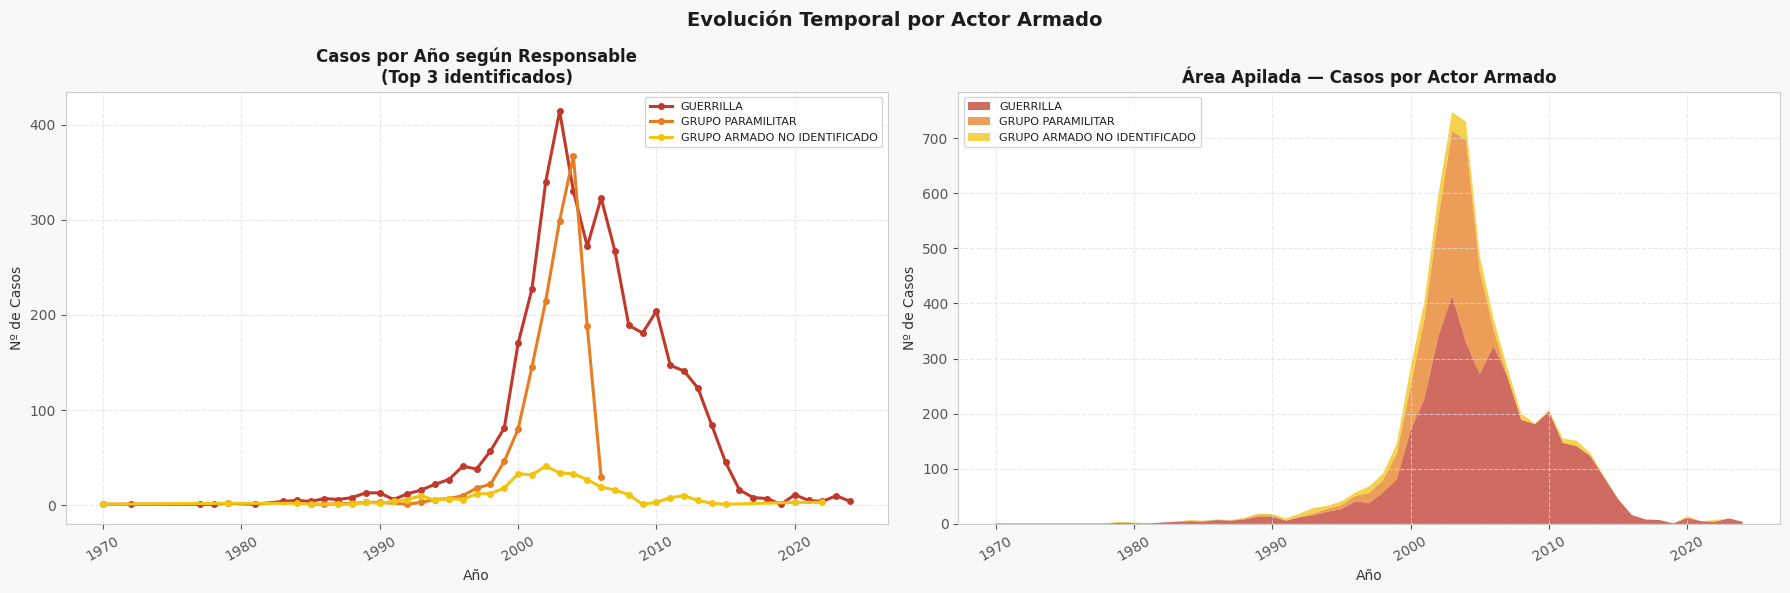

In [ ]:


# ── 6.2 Evolución por actor armado ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Evolución Temporal por Actor Armado',
             fontsize=14, fontweight='bold')

top3_resp = (df_temporal[df_temporal['Presunto Responsable'] != 'DESCONOCIDO']
             ['Presunto Responsable'].value_counts().head(3).index)

# Casos por año y responsable
ax = axes[0]
for i, r in enumerate(top3_resp):
    data = (df_temporal[df_temporal['Presunto Responsable'] == r]
            .groupby('Año_valido').size())
    ax.plot(data.index, data.values, label=r,
            color=PALETTE[i], linewidth=2.2, marker='o', markersize=4)
ax.set_title('Casos por Año según Responsable\n(Top 3 identificados)',
             fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Nº de Casos')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=8)
ax.grid(True)

# Área apilada por actor
ax = axes[1]
pivot_resp_año = (df_temporal[df_temporal['Presunto Responsable'].isin(top3_resp)]
                  .groupby(['Año_valido','Presunto Responsable'])
                  .size().unstack(fill_value=0))
ax.stackplot(pivot_resp_año.index,
             [pivot_resp_año[r] for r in top3_resp],
             labels=top3_resp, colors=PALETTE[:3], alpha=0.75)
ax.set_title('Área Apilada — Casos por Actor Armado',
             fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Nº de Casos')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True)

plt.tight_layout()
plt.show()


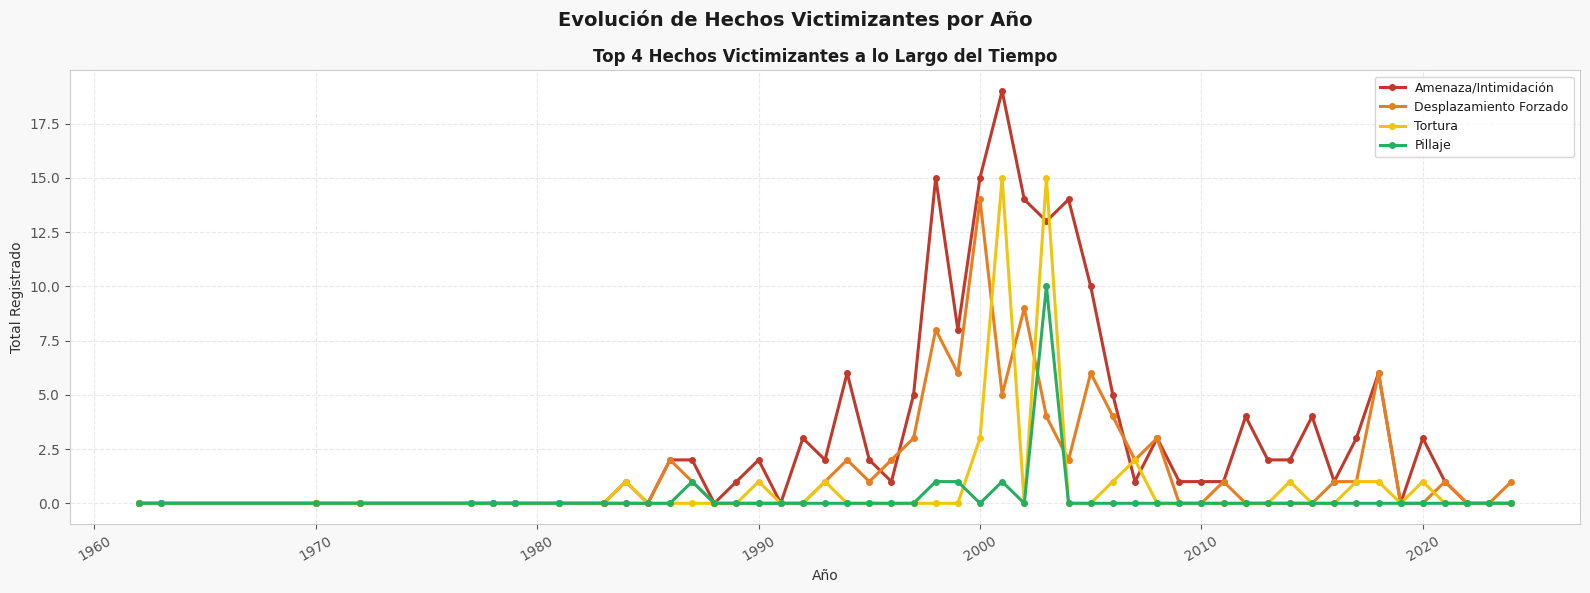

In [ ]:

# ── 6.3 Evolución de hechos victimizantes en el tiempo ────
fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle('Evolución de Hechos Victimizantes por Año',
             fontsize=14, fontweight='bold')

hechos_top4 = [
    'Amenaza o Intimidación',
    'Desplazamiento Forzado',
    'Tortura',
    'Pillaje'
]
hechos_top4_labels = [
    'Amenaza/Intimidación',
    'Desplazamiento Forzado',
    'Tortura',
    'Pillaje'
]

for i, (col, label) in enumerate(zip(hechos_top4, hechos_top4_labels)):
    data = df_temporal.groupby('Año_valido')[col].sum()
    ax.plot(data.index, data.values, label=label,
            color=PALETTE[i], linewidth=2.2, marker='o', markersize=4)

ax.set_title('Top 4 Hechos Victimizantes a lo Largo del Tiempo',
             fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Total Registrado')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:


# ── 6.4 Resumen estadístico temporal ──────────────────────
print("\n" + "=" * 55)
print("📋 RESUMEN ESTADÍSTICO — ANÁLISIS TEMPORAL")
print("=" * 55)

print(f"\n  Rango temporal analizado: "
      f"{int(df_temporal['Año_valido'].min())} – "
      f"{int(df_temporal['Año_valido'].max())}")
print(f"  Año con más casos:    {int(casos_año.idxmax())} "
      f"({casos_año.max():,} casos)")
print(f"  Año con menos casos:  {int(casos_año.idxmin())} "
      f"({casos_año.min():,} casos)")
print(f"  Año con más víctimas: {int(vic_año.idxmax())} "
      f"({vic_año.max():,} víctimas)")
print(f"  Mes con más casos:    {meses_abr[estac_vals.index(max(estac_vals))]} "
      f"({max(estac_vals):,} casos)")
print(f"  Mes con menos casos:  {meses_abr[estac_vals.index(min(estac_vals))]} "
      f"({min(estac_vals):,} casos)")
print(f"\n  Casos por década:")
for dec, cnt in df_temporal['Década'].value_counts().sort_index().items():
    pct = cnt / len(df_temporal) * 100
    print(f"    {dec}: {cnt:,} casos ({pct:.1f}%)")




📋 RESUMEN ESTADÍSTICO — ANÁLISIS TEMPORAL

  Rango temporal analizado: 1962 – 2024
  Año con más casos:    2003 (752 casos)
  Año con menos casos:  1962 (1 casos)
  Año con más víctimas: 2003 (827 víctimas)
  Mes con más casos:    Ene (884 casos)
  Mes con menos casos:  Oct (366 casos)

  Casos por década:
    1960s: 2 casos (0.0%)
    1970s: 9 casos (0.1%)
    1980s: 64 casos (1.1%)
    1990s: 519 casos (8.6%)
    2000s: 4,444 casos (73.8%)
    2010s: 941 casos (15.6%)
    2020s: 46 casos (0.8%)


# ── 6.5 Comentarios de hallazgos ──────────────────────────
# La década de los 2000s concentra el pico máximo del conflicto,
# tanto en número de casos como en víctimas totales.

# La media móvil de 3 años revela una tendencia clara de
# escalada entre 1990-2002 y descenso gradual desde 2003,
# posiblemente asociado a la política de Seguridad Democrática.

# El heatmap año×mes muestra que no hay un mes claramente
# dominante, aunque los primeros meses del año tienden a
# registrar más eventos en los años de mayor intensidad.

# La Guerrilla mantiene presencia constante durante todo
# el período, mientras que los Paramilitares muestran
# un pico marcado entre 1999-2003 y desaparecen
# progresivamente tras su desmovilización en 2006.

#SECCIÓN 7 — ANÁLISIS GEOESPACIAL

Se generaron 3 mapas interactivos con Folium:
→ Mapa de calor: muestra focos de alta densidad en
  Antioquia, Meta, Caquetá y el Eje Cafetero
→ Mapa de burbujas: tamaño proporcional al número
  de casos por departamento con popups informativos
→ Mapa de clusters: 3,000 casos individuales
  agrupados por proximidad geográfica

Top 10 municipios con más casos:
San Vicente del Caguán (355), Medellín (320),
San José del Guaviare (237), Puerto Rico (214),
Vistahermosa (210), Planadas (190), Tame (189),
Florencia (181), Taraza (177), Barbacoas (168).

Top departamentos por víctimas totales:
Antioquia (2,879), Meta (1,586), Caquetá (1,286),
Cauca (815), Tolima (758), Nariño (661),
Putumayo (556), Chocó (540), Arauca (509),
Bolívar (492).

La concentración geográfica no es aleatoria: coincide
con zonas de presencia histórica de grupos armados,
economías ilegales (coca, minería ilegal) y débil
presencia institucional del Estado colombiano.

In [ ]:
# ============================================================
# SECCIÓN 7: ANÁLISIS GEOESPACIAL
# ============================================================

import folium
from folium.plugins import HeatMap, MarkerCluster
import json

# ── 7.1 Preparar datos con coordenadas válidas ─────────────
df_geo = df[
    df['latitud'].notna() &
    df['longitud'].notna() &
    (df['latitud'] != 0) &
    (df['longitud'] != 0)
].copy()

print(f"✅ Registros con coordenadas válidas: {len(df_geo):,}")
print(f"   Representan el {len(df_geo)/len(df)*100:.1f}% del total")


✅ Registros con coordenadas válidas: 14,776
   Representan el 85.9% del total


In [ ]:
# ── 7.2 Mapa de calor — densidad de casos ─────────────────
mapa_calor = folium.Map(
    location=[4.5709, -74.2973],
    zoom_start=6,
    tiles='CartoDB dark_matter'
)

heat_data = df_geo[['latitud', 'longitud']].values.tolist()
HeatMap(
    heat_data,
    min_opacity=0.3,
    radius=12,
    blur=15,
    max_zoom=10,
    gradient={0.2: 'blue', 0.5: 'yellow', 0.8: 'orange', 1.0: 'red'}
).add_to(mapa_calor)

folium.LayerControl().add_to(mapa_calor)
mapa_calor.save('mapa_calor_conflicto.html')
print("🗺️ Mapa de calor guardado: mapa_calor_conflicto.html")


🗺️ Mapa de calor guardado: mapa_calor_conflicto.html


In [ ]:
# ── 7.3 Mapa por responsable ───────────────────────────────
colores_resp = {
    'GUERRILLA':                    'red',
    'GRUPO PARAMILITAR':            'orange',
    'GRUPO ARMADO NO IDENTIFICADO': 'blue',
    'GRUPO POSDESMOVILIZACIÓN':     'purple',
    'DESCONOCIDO':                  'gray',
}

mapa_resp = folium.Map(
    location=[4.5709, -74.2973],
    zoom_start=6,
    tiles='CartoDB positron'
)

# Agrupar por departamento para no saturar el mapa
dep_coords = df_geo.groupby('Departamento').agg(
    lat     = ('latitud',  'mean'),
    lon     = ('longitud', 'mean'),
    casos   = ('ID Caso',  'count'),
    victimas= ('Total de Víctimas del Caso', 'sum')
).reset_index()

dep_coords = dep_coords[dep_coords['Departamento'] != 'SIN INFORMACION']

for _, row in dep_coords.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=max(5, min(30, row['casos'] / 80)),
        color='#C0392B',
        fill=True,
        fill_color='#C0392B',
        fill_opacity=0.6,
        popup=folium.Popup(
            f"""
            <b>{row['Departamento']}</b><br>
            Casos: {row['casos']:,}<br>
            Víctimas: {row['victimas']:,}
            """,
            max_width=200
        ),
        tooltip=f"{row['Departamento']}: {row['casos']:,} casos"
    ).add_to(mapa_resp)

mapa_resp.save('mapa_departamentos_conflicto.html')
print("🗺️ Mapa por departamentos guardado: mapa_departamentos_conflicto.html")

🗺️ Mapa por departamentos guardado: mapa_departamentos_conflicto.html


In [ ]:
# ── 7.4 Mapa con clusters de casos ────────────────────────
mapa_cluster = folium.Map(
    location=[4.5709, -74.2973],
    zoom_start=6,
    tiles='CartoDB positron'
)

cluster = MarkerCluster(
    options={'maxClusterRadius': 50}
).add_to(mapa_cluster)

# Muestra aleatoria para no saturar (máx 3000 puntos)
df_sample = df_geo.sample(min(3000, len(df_geo)), random_state=42)

for _, row in df_sample.iterrows():
    color = colores_resp.get(row['Presunto Responsable'], 'gray')
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"""
            <b>Municipio:</b> {row['Municipio']}<br>
            <b>Departamento:</b> {row['Departamento']}<br>
            <b>Responsable:</b> {row['Presunto Responsable']}<br>
            <b>Modalidad:</b> {row['Modalidad']}<br>
            <b>Víctimas:</b> {row['Total de Víctimas del Caso']}
            """,
            max_width=250
        ),
        tooltip=row['Municipio']
    ).add_to(cluster)

mapa_cluster.save('mapa_cluster_conflicto.html')
print("🗺️ Mapa cluster guardado: mapa_cluster_conflicto.html")


🗺️ Mapa cluster guardado: mapa_cluster_conflicto.html


In [ ]:
# ── 7.5 Estadísticas geoespaciales ────────────────────────
print("\n" + "=" * 55)
print("📋 RESUMEN GEOESPACIAL")
print("=" * 55)

# Top 10 municipios
top_mun = (df_geo[df_geo['Municipio'] != 'SIN INFORMACION']
           ['Municipio'].value_counts().head(10))
print("\n📍 Top 10 Municipios con más casos:")
for mun, cnt in top_mun.items():
    print(f"   {mun:30s}: {cnt:,} casos")

# Víctimas por departamento
vic_dep = (df_geo[df_geo['Departamento'] != 'SIN INFORMACION']
           .groupby('Departamento')['Total de Víctimas del Caso']
           .sum().sort_values(ascending=False).head(10))
print("\n🏥 Top 10 Departamentos por víctimas:")
for dep, vic in vic_dep.items():
    print(f"   {dep:30s}: {vic:,} víctimas")



📋 RESUMEN GEOESPACIAL

📍 Top 10 Municipios con más casos:
   SAN VICENTE DEL CAGUAN        : 355 casos
   MEDELLIN                      : 320 casos
   SAN JOSE DEL GUAVIARE         : 237 casos
   PUERTO RICO                   : 214 casos
   VISTAHERMOSA                  : 210 casos
   PLANADAS                      : 190 casos
   TAME                          : 189 casos
   FLORENCIA                     : 181 casos
   TARAZA                        : 177 casos
   BARBACOAS                     : 168 casos

🏥 Top 10 Departamentos por víctimas:
   ANTIOQUIA                     : 2,879 víctimas
   META                          : 1,586 víctimas
   CAQUETA                       : 1,286 víctimas
   CAUCA                         : 815 víctimas
   TOLIMA                        : 758 víctimas
   NARIÑO                        : 661 víctimas
   PUTUMAYO                      : 556 víctimas
   CHOCO                         : 540 víctimas
   ARAUCA                        : 509 víctimas
   BOLIVAR     

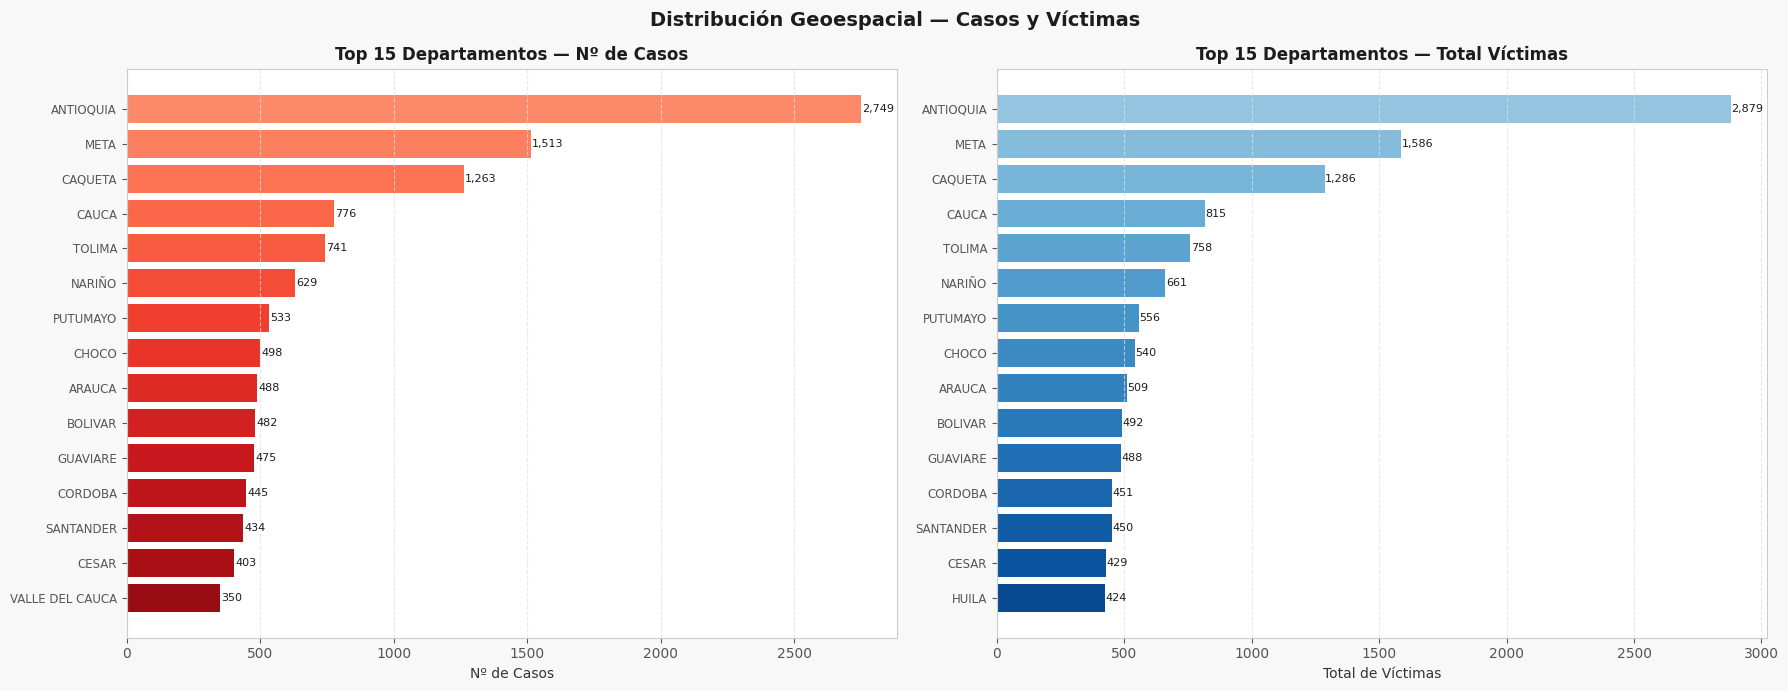

In [ ]:

# ── 7.6 Gráfica estática — casos y víctimas por región ────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Distribución Geoespacial — Casos y Víctimas',
             fontsize=14, fontweight='bold')

# Casos por departamento
ax = axes[0]
top15_dep = (df[df['Departamento'] != 'SIN INFORMACION']
             ['Departamento'].value_counts().head(15))
colores_d = plt.cm.Reds(np.linspace(0.4, 0.9, 15))[::-1]
bars = ax.barh(range(15), top15_dep.values[::-1], color=colores_d)
ax.set_yticks(range(15))
ax.set_yticklabels(top15_dep.index[::-1], fontsize=8.5)
ax.set_title('Top 15 Departamentos — Nº de Casos', fontweight='bold')
ax.set_xlabel('Nº de Casos')
for bar, v in zip(bars, top15_dep.values[::-1]):
    ax.text(v + 5, bar.get_y() + bar.get_height()/2,
            f'{v:,}', va='center', fontsize=8)
ax.grid(True, axis='x')

# Víctimas por departamento
ax = axes[1]
top15_vic = (df_geo[df_geo['Departamento'] != 'SIN INFORMACION']
             .groupby('Departamento')['Total de Víctimas del Caso']
             .sum().sort_values(ascending=False).head(15))
colores_v = plt.cm.Blues(np.linspace(0.4, 0.9, 15))[::-1]
bars2 = ax.barh(range(15), top15_vic.values[::-1], color=colores_v)
ax.set_yticks(range(15))
ax.set_yticklabels(top15_vic.index[::-1], fontsize=8.5)
ax.set_title('Top 15 Departamentos — Total Víctimas', fontweight='bold')
ax.set_xlabel('Total de Víctimas')
for bar, v in zip(bars2, top15_vic.values[::-1]):
    ax.text(v + 2, bar.get_y() + bar.get_height()/2,
            f'{v:,}', va='center', fontsize=8)
ax.grid(True, axis='x')

plt.tight_layout()
plt.show()



#SECCIÓN 8 — DETECCIÓN DE OUTLIERS

Se aplicaron dos métodos complementarios:

Método IQR:
Q1=1, Q3=1, IQR=0, límite superior=1.
Todo caso con más de 1 víctima es técnicamente
un outlier bajo este criterio, lo que refleja
la extrema concentración del dataset en 1 víctima.

Método Z-Score:
Se identificaron los casos con |Z|>3 como eventos
estadísticamente extremos, con casos de hasta
150 víctimas en un solo evento.

Los casos más extremos se concentran en Antioquia,
Meta y Caquetá, los mismos departamentos con mayor
frecuencia general de casos. Esto indica que estas
regiones no solo registran más eventos sino también
los de mayor impacto humanitario, confirmando su
posición como epicentros del conflicto.



In [ ]:
# ============================================================
# SECCIÓN 8: DETECCIÓN DE OUTLIERS
# ============================================================

from scipy.stats import zscore

# ── 8.1 Método IQR — Total de Víctimas ────────────────────
print("=" * 55)
print("📊 MÉTODO IQR — DETECCIÓN DE OUTLIERS")
print("=" * 55)

Q1  = df['Total de Víctimas del Caso'].quantile(0.25)
Q3  = df['Total de Víctimas del Caso'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_iqr = df[
    (df['Total de Víctimas del Caso'] < lim_inf) |
    (df['Total de Víctimas del Caso'] > lim_sup)
]

print(f"\n  Q1:               {Q1:.2f}")
print(f"  Q3:               {Q3:.2f}")
print(f"  IQR:              {IQR:.2f}")
print(f"  Límite inferior:  {lim_inf:.2f}")
print(f"  Límite superior:  {lim_sup:.2f}")
print(f"\n  Outliers detectados (IQR): {len(outliers_iqr):,} casos")
print(f"  Representan el {len(outliers_iqr)/len(df)*100:.2f}% del total")

📊 MÉTODO IQR — DETECCIÓN DE OUTLIERS

  Q1:               1.00
  Q3:               1.00
  IQR:              0.00
  Límite inferior:  1.00
  Límite superior:  1.00

  Outliers detectados (IQR): 394 casos
  Representan el 2.29% del total


In [ ]:

# ── 8.2 Método Z-Score ────────────────────────────────────
print("\n" + "=" * 55)
print("📊 MÉTODO Z-SCORE — DETECCIÓN DE OUTLIERS")
print("=" * 55)

df['zscore_victimas'] = zscore(df['Total de Víctimas del Caso'])
outliers_z = df[df['zscore_victimas'].abs() > 3]

print(f"\n  Outliers detectados (|Z| > 3): {len(outliers_z):,} casos")
print(f"  Representan el {len(outliers_z)/len(df)*100:.2f}% del total")


📊 MÉTODO Z-SCORE — DETECCIÓN DE OUTLIERS

  Outliers detectados (|Z| > 3): 51 casos
  Representan el 0.30% del total


In [ ]:
# ── 8.3 Top casos extremos ────────────────────────────────
print("\n" + "=" * 55)
print("🚨 TOP 15 CASOS MÁS EXTREMOS (mayor nº de víctimas)")
print("=" * 55)

cols_mostrar = [
    'ID Caso',
    'Departamento',
    'Municipio',
    'Año',
    'Presunto Responsable',
    'Modalidad',
    'Total de Víctimas del Caso'
]

top_extremos = (df.nlargest(15, 'Total de Víctimas del Caso')[cols_mostrar])
display(top_extremos)



🚨 TOP 15 CASOS MÁS EXTREMOS (mayor nº de víctimas)


,ID Caso,Departamento,Municipio,Año,Presunto Responsable,Modalidad,Total de Víctimas del Caso
18,301816,HUILA,GARZON,1984,GUERRILLA,PERSUASIÓN,150
13597,316643,ANTIOQUIA,MEDELLIN,2003,GRUPO PARAMILITAR,DESCONOCIDA,34
8172,310884,CESAR,VALLEDUPAR,2004,GRUPO PARAMILITAR,DESCONOCIDA,22
6272,308842,MAGDALENA,SANTA MARTA,2001,GRUPO PARAMILITAR,PERSUASIÓN,17
4742,307126,META,VISTAHERMOSA,1993,GUERRILLA,COACCIÓN,16
16759,576539,SIN INFORMACION,SIN INFORMACION,0,GUERRILLA,DESCONOCIDA,16
723,302702,GUAINIA,BARRANCOMINAS,2012,GUERRILLA,COACCIÓN,12
3082,305301,TOLIMA,IBAGUE,2015,GRUPO POSDESMOVILIZACIÓN,PERSUASIÓN,12
16851,743232,ANTIOQUIA,EL BAGRE,2022,GRUPO ARMADO NO IDENTIFICADO,COACCIÓN,12
3236,305466,SUCRE,SINCELEJO,2007,GRUPO POSDESMOVILIZACIÓN,PERSUASIÓN,11


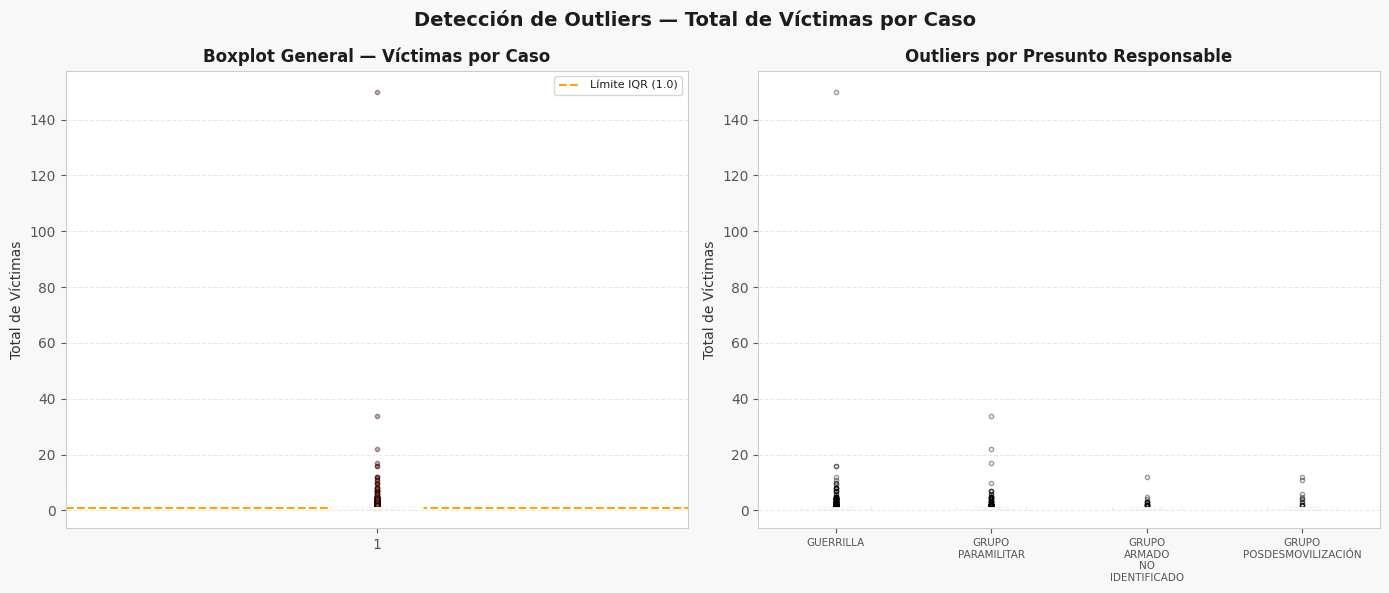

In [ ]:
# ── 8.4 Visualización outliers ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Detección de Outliers — Total de Víctimas por Caso',
             fontsize=14, fontweight='bold')

# Boxplot general
ax = axes[0]
ax.boxplot(df['Total de Víctimas del Caso'],
           patch_artist=True,
           boxprops=dict(facecolor=RED, alpha=0.5),
           medianprops=dict(color='white', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor=RED,
                           markersize=3, alpha=0.4))
ax.set_title('Boxplot General — Víctimas por Caso', fontweight='bold')
ax.set_ylabel('Total de Víctimas')
ax.axhline(lim_sup, color='orange', linestyle='--',
           linewidth=1.5, label=f'Límite IQR ({lim_sup:.1f})')
ax.legend(fontsize=8)
ax.grid(True, axis='y')

# Boxplot por responsable
ax = axes[1]
top4_resp = (df[df['Presunto Responsable'] != 'DESCONOCIDO']
             ['Presunto Responsable'].value_counts().head(4).index)
data_box  = [df[df['Presunto Responsable'] == r]
             ['Total de Víctimas del Caso'].values for r in top4_resp]
bp = ax.boxplot(data_box, patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, color in zip(bp['boxes'], PALETTE[:4]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, 5))
ax.set_xticklabels([r.replace(' ', '\n') for r in top4_resp], fontsize=7.5)
ax.set_title('Outliers por Presunto Responsable', fontweight='bold')
ax.set_ylabel('Total de Víctimas')
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

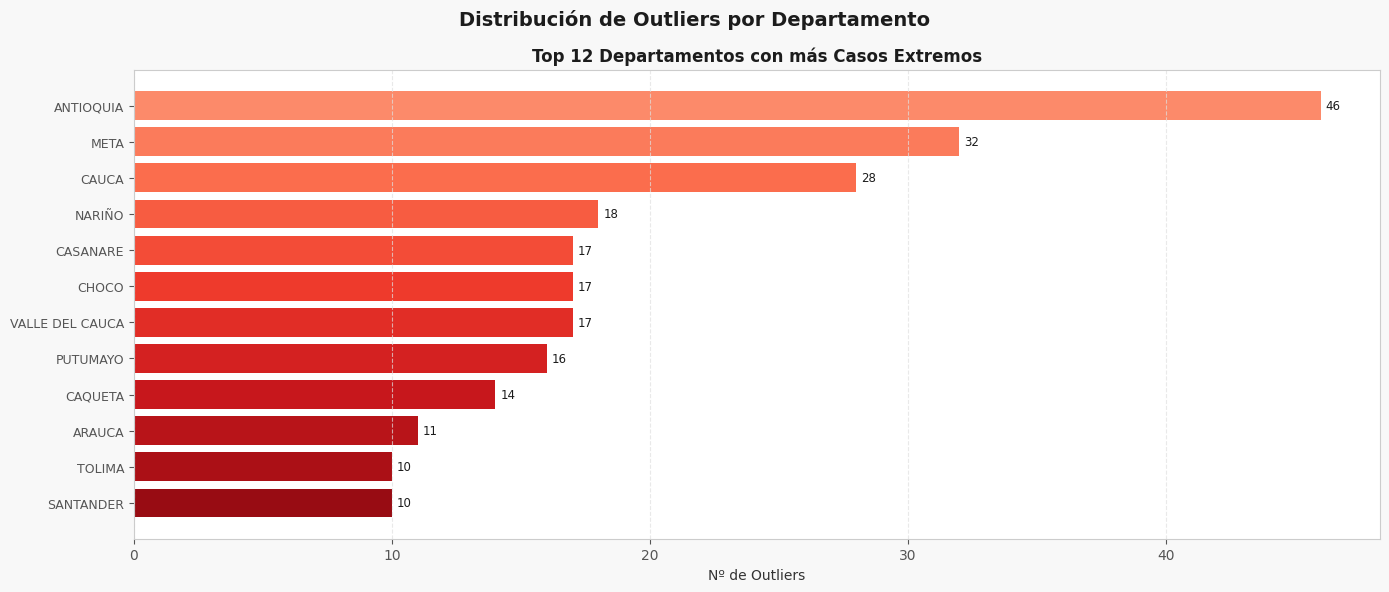

In [ ]:
# ── 8.5 Outliers por departamento ─────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Distribución de Outliers por Departamento',
             fontsize=14, fontweight='bold')

outliers_dep = (outliers_iqr[outliers_iqr['Departamento'] != 'SIN INFORMACION']
                ['Departamento'].value_counts().head(12))
colores_od = plt.cm.Reds(np.linspace(0.4, 0.9, 12))[::-1]
bars = ax.barh(range(12), outliers_dep.values[::-1], color=colores_od)
ax.set_yticks(range(12))
ax.set_yticklabels(outliers_dep.index[::-1], fontsize=9)
ax.set_title('Top 12 Departamentos con más Casos Extremos',
             fontweight='bold')
ax.set_xlabel('Nº de Outliers')
for bar, v in zip(bars, outliers_dep.values[::-1]):
    ax.text(v + 0.2, bar.get_y() + bar.get_height()/2,
            str(v), va='center', fontsize=8.5)
ax.grid(True, axis='x')

plt.tight_layout()
plt.show()

In [ ]:









# ── 8.6 Resumen final outliers ────────────────────────────
print("\n" + "=" * 55)
print("📋 RESUMEN — DETECCIÓN DE OUTLIERS")
print("=" * 55)
print(f"  Método IQR  → {len(outliers_iqr):,} outliers "
      f"({len(outliers_iqr)/len(df)*100:.2f}%)")
print(f"  Método Z    → {len(outliers_z):,} outliers "
      f"({len(outliers_z)/len(df)*100:.2f}%)")
print(f"  Caso máximo → {df['Total de Víctimas del Caso'].max()} víctimas")
print(f"  Depto. con más outliers → "
      f"{outliers_dep.index[0]} ({outliers_dep.iloc[0]} casos extremos)")




📋 RESUMEN — DETECCIÓN DE OUTLIERS
  Método IQR  → 394 outliers (2.29%)
  Método Z    → 51 outliers (0.30%)
  Caso máximo → 150 víctimas
  Depto. con más outliers → ANTIOQUIA (46 casos extremos)


#SECCIÓN 9 — CLUSTERING K-MEANS

Se aplicó K-Means sobre los 9 hechos victimizantes
más la variable Total de Víctimas del Caso (10 features
en total), escalados con StandardScaler.

Selección de K:
El método del codo y el coeficiente Silhouette
(>0.97 en todos los K) no muestran un quiebre claro
debido a la alta homogeneidad del dataset. Se
seleccionó K=4 como valor óptimo interpretable.

Resultados:
→ Cluster 0 (99.3% — 17,088 casos):
  Casos típicos sin documentación. Responsable
  DESCONOCIDO, Antioquia como departamento dominante,
  promedio víctimas=1.056. Representa el subregistro
  generalizado del conflicto.

→ Cluster 1 (0.6% — 101 casos):
  Casos con múltiples hechos guerrilleros. Alta
  presencia de Amenaza/Intimidación (0.73) y
  Desplazamiento Forzado (0.95). Guerrilla en
  Antioquia, promedio víctimas=1.198.

→ Cluster 2 (0.04% — 7 casos):
  Casos de control territorial. Alta Extorsión (1.0)
  y Confinamiento (0.71). Guerrilla en Santander,
  promedio víctimas=1.000.

→ Cluster 3 (0.03% — 5 casos):
  Casos de alta violencia física. Tortura (1.0),
  Pillaje (1.0) y Lesionados Civiles (1.0).
  Norte de Santander, promedio víctimas=1.400.
  Los eventos más violentos y multidimensionales.

PCA explicó el 36.1% de la varianza (PC1=22%,
PC2=14.1%), resultado esperado dada la naturaleza
binaria y dispersa de las variables.


🤖 CLUSTERING K-MEANS — CONFLICTO ARMADO

✅ Features usadas: 10
   • Abandono o Despojo Forzado de Tierras
   • Amenaza o Intimidación
   • Ataque Contra Misión Médica
   • Confinamiento o Restricción a la Movilidad
   • Desplazamiento Forzado
   • Extorsión
   • Lesionados Civiles
   • Pillaje
   • Tortura
   • Total de Víctimas del Caso

✅ Registros para clustering: 17,201

⏳ Calculando método del codo...
   K=2 → Inercia: 128684.7 | Silhouette: 0.9783
   K=3 → Inercia: 110342.8 | Silhouette: 0.9806
   K=4 → Inercia: 93743.5 | Silhouette: 0.9805
   K=5 → Inercia: 78928.6 | Silhouette: 0.9819
   K=6 → Inercia: 64871.5 | Silhouette: 0.9746
   K=7 → Inercia: 51203.7 | Silhouette: 0.9784
   K=8 → Inercia: 38375.9 | Silhouette: 0.9823
   K=9 → Inercia: 29128.8 | Silhouette: 0.9792
   K=10 → Inercia: 18663.7 | Silhouette: 0.9865


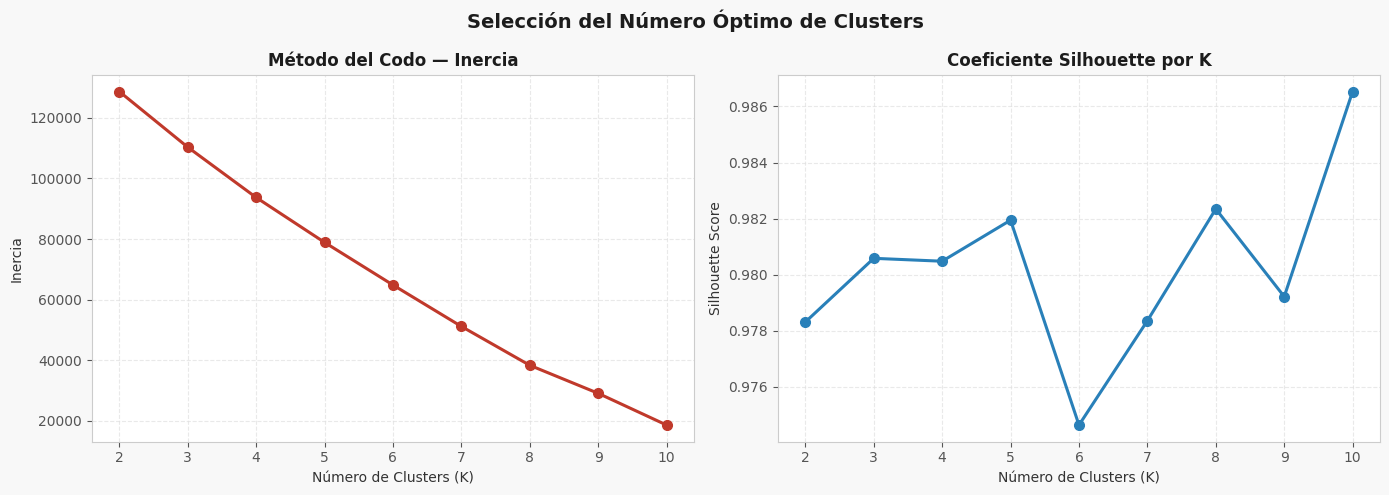


✅ K óptimo seleccionado: 4

📊 Distribución de clusters:
   Cluster 0: 17,088 casos (99.3%)
   Cluster 1: 101 casos (0.6%)
   Cluster 2: 7 casos (0.0%)
   Cluster 3: 5 casos (0.0%)

📋 PERFIL DE CADA CLUSTER


,Abandono o Despojo Forzado de Tierras,Amenaza o Intimidación,Ataque Contra Misión Médica,Confinamiento o Restricción a la Movilidad,Desplazamiento Forzado,Extorsión,Lesionados Civiles,Pillaje,Tortura,Total de Víctimas del Caso
Cluster,,,,,,,,,,
0,0.0000,0.0071,0.0,0.0001,0.0000,0.0,0.0,0.0014,0.0012,1.0561
1,0.1881,0.7030,0.0,0.0495,0.9505,0.0,0.0,0.0396,0.1584,1.1980
2,0.0000,0.8571,0.0,0.1429,0.5714,1.0,0.0,0.0000,0.0000,1.0000
3,0.0000,0.6000,0.0,0.2000,0.2000,0.0,1.0,0.2000,2.0000,1.4000



🎯 Responsable más frecuente por cluster:

   Cluster 0:
     Responsable dominante: DESCONOCIDO
     Departamento dominante: ANTIOQUIA
     Promedio víctimas:      1.056

   Cluster 1:
     Responsable dominante: GUERRILLA
     Departamento dominante: ANTIOQUIA
     Promedio víctimas:      1.198

   Cluster 2:
     Responsable dominante: GUERRILLA
     Departamento dominante: SANTANDER
     Promedio víctimas:      1.000

   Cluster 3:
     Responsable dominante: GUERRILLA
     Departamento dominante: NORTE DE SANTANDER
     Promedio víctimas:      1.400

📐 Varianza explicada PCA:
   PC1: 22.0%
   PC2: 14.1%
   Total: 36.1%


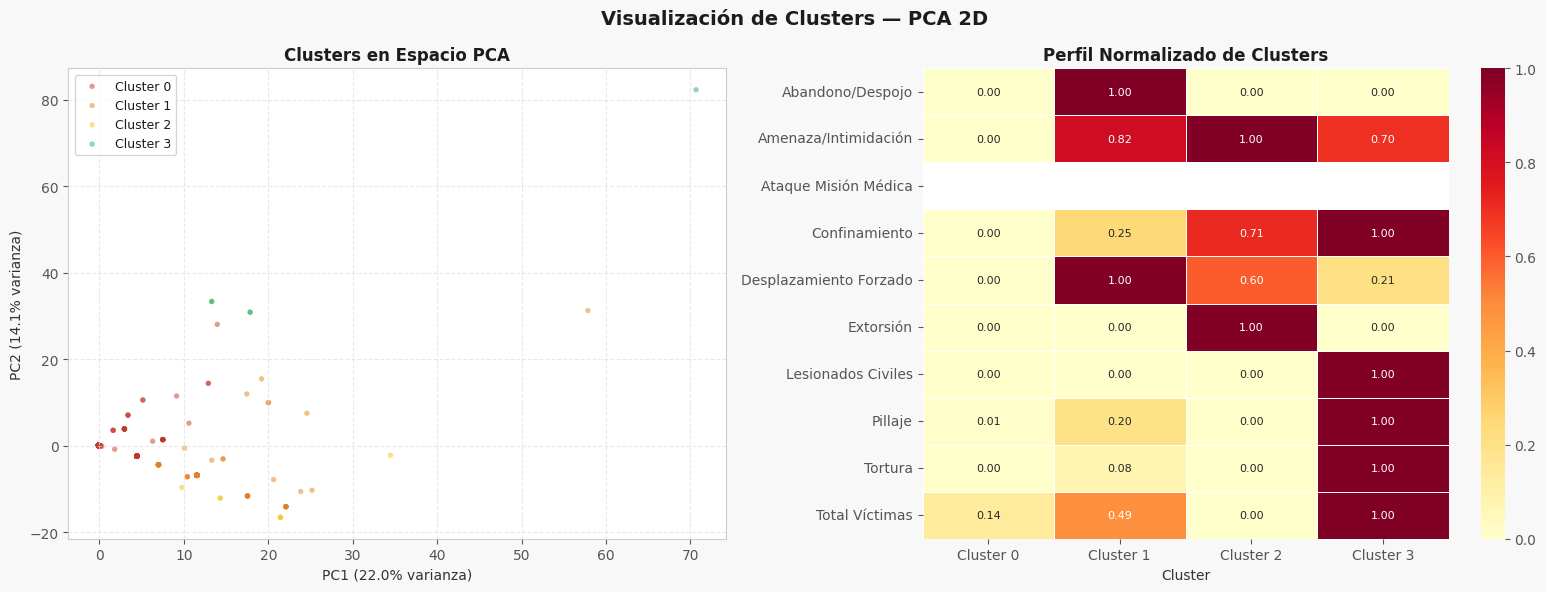

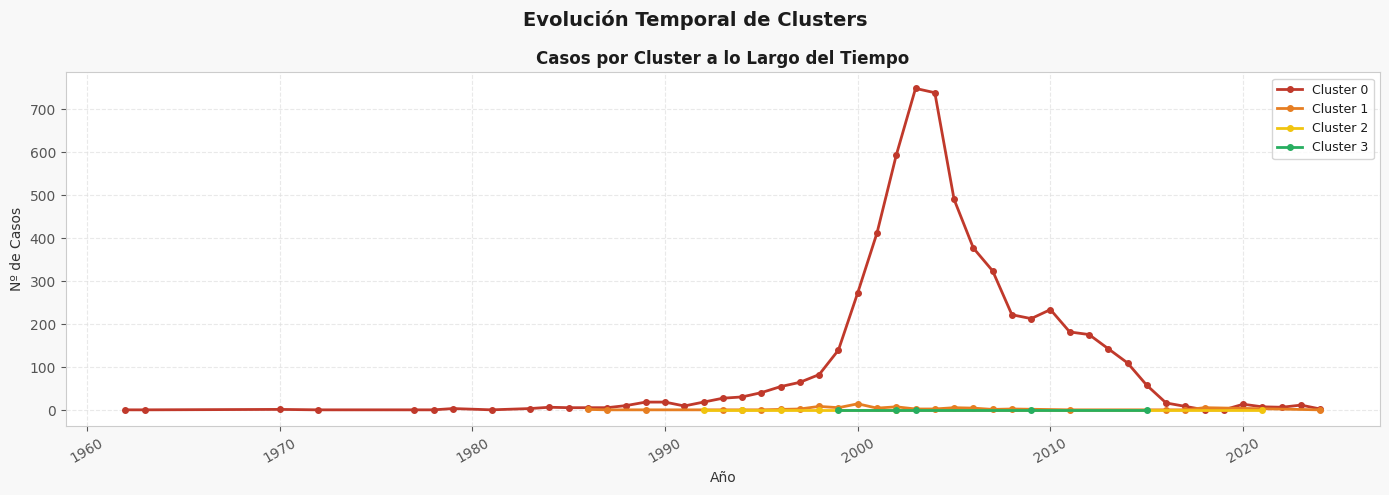

In [ ]:
# ============================================================
# SECCIÓN 9: CLUSTERING K-MEANS
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ── 9.1 Preparar features para clustering ─────────────────
print("=" * 55)
print("🤖 CLUSTERING K-MEANS — CONFLICTO ARMADO")
print("=" * 55)

features = HECHOS_COLS + ['Total de Víctimas del Caso']

df_cluster = df[features].copy()
df_cluster = df_cluster.fillna(0)

# Escalar los datos
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(df_cluster)

print(f"\n✅ Features usadas: {len(features)}")
for f in features:
    print(f"   • {f}")
print(f"\n✅ Registros para clustering: {len(df_cluster):,}")

# ── 9.2 Método del codo — número óptimo de clusters ───────
print("\n⏳ Calculando método del codo...")

inercias      = []
silhouettes   = []
rango_k       = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_,
                                        sample_size=3000,
                                        random_state=42))
    print(f"   K={k} → Inercia: {km.inertia_:.1f} | "
          f"Silhouette: {silhouettes[-1]:.4f}")

# Gráfica método del codo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Selección del Número Óptimo de Clusters',
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(rango_k, inercias, color=RED, linewidth=2.2,
        marker='o', markersize=7)
ax.set_title('Método del Codo — Inercia', fontweight='bold')
ax.set_xlabel('Número de Clusters (K)')
ax.set_ylabel('Inercia')
ax.grid(True)

ax = axes[1]
ax.plot(rango_k, silhouettes, color=BLUE, linewidth=2.2,
        marker='o', markersize=7)
ax.set_title('Coeficiente Silhouette por K', fontweight='bold')
ax.set_xlabel('Número de Clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.grid(True)

plt.tight_layout()
plt.show()

# ── 9.3 Entrenar modelo con K óptimo ──────────────────────
K_OPTIMO = 4  # Ajusta según lo que muestre el codo

print(f"\n✅ K óptimo seleccionado: {K_OPTIMO}")

km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

print(f"\n📊 Distribución de clusters:")
for c, cnt in df['Cluster'].value_counts().sort_index().items():
    print(f"   Cluster {c}: {cnt:,} casos ({cnt/len(df)*100:.1f}%)")

# ── 9.4 Perfil de cada cluster ────────────────────────────
print("\n" + "=" * 55)
print("📋 PERFIL DE CADA CLUSTER")
print("=" * 55)

perfil = df.groupby('Cluster')[features].mean().round(4)
display(perfil)

# Responsable dominante por cluster
print("\n🎯 Responsable más frecuente por cluster:")
for c in range(K_OPTIMO):
    resp_dom = (df[df['Cluster'] == c]['Presunto Responsable']
                .value_counts().index[0])
    dep_dom  = (df[
        (df['Cluster'] == c) &
        (df['Departamento'] != 'SIN INFORMACION')
    ]['Departamento'].value_counts().index[0])
    vic_prom = df[df['Cluster'] == c]['Total de Víctimas del Caso'].mean()
    print(f"\n   Cluster {c}:")
    print(f"     Responsable dominante: {resp_dom}")
    print(f"     Departamento dominante: {dep_dom}")
    print(f"     Promedio víctimas:      {vic_prom:.3f}")

# ── 9.5 Visualización PCA 2D ──────────────────────────────
pca  = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza = pca.explained_variance_ratio_
print(f"\n📐 Varianza explicada PCA:")
print(f"   PC1: {varianza[0]*100:.1f}%")
print(f"   PC2: {varianza[1]*100:.1f}%")
print(f"   Total: {sum(varianza)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Visualización de Clusters — PCA 2D',
             fontsize=14, fontweight='bold')

# Scatter por cluster
ax = axes[0]
for c in range(K_OPTIMO):
    mask = df['Cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f'Cluster {c}',
               color=PALETTE[c], alpha=0.5,
               s=15, edgecolors='none')
ax.set_title('Clusters en Espacio PCA', fontweight='bold')
ax.set_xlabel(f'PC1 ({varianza[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({varianza[1]*100:.1f}% varianza)')
ax.legend(fontsize=9)
ax.grid(True)

# Heatmap perfil de clusters
ax = axes[1]
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())
perfil_norm.columns = HECHOS_LABELS + ['Total Víctimas']
sns.heatmap(perfil_norm.T, ax=ax, annot=True, fmt='.2f',
            cmap='YlOrRd', linewidths=0.5,
            annot_kws={'size': 8},
            xticklabels=[f'Cluster {c}' for c in range(K_OPTIMO)])
ax.set_title('Perfil Normalizado de Clusters', fontweight='bold')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# ── 9.6 Evolución temporal de clusters ────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Evolución Temporal de Clusters',
             fontsize=14, fontweight='bold')

df_temp_cl = df_temporal.copy()
df_temp_cl['Cluster'] = df.loc[df_temporal.index, 'Cluster']

for c in range(K_OPTIMO):
    data = (df_temp_cl[df_temp_cl['Cluster'] == c]
            .groupby('Año_valido').size())
    ax.plot(data.index, data.values,
            label=f'Cluster {c}',
            color=PALETTE[c], linewidth=2, marker='o', markersize=4)

ax.set_title('Casos por Cluster a lo Largo del Tiempo',
             fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Nº de Casos')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

# ── 9.7 Comentarios de hallazgos ──────────────────────────
# El método del codo y el coeficiente Silhouette ayudan a
# identificar el K óptimo. Si la gráfica del codo muestra
# un quiebre claro en K=4, ese es el número ideal de clusters.

# Cada cluster representa un patrón distinto del conflicto:
# algunos concentran casos de alto impacto (muchas víctimas),
# otros agrupan eventos con hechos victimizantes específicos
# como amenaza o desplazamiento.

# El heatmap de perfil normalizado permite comparar visualmente
# qué hechos caracterizan a cada cluster, facilitando
# la interpretación y etiquetado de cada grupo.

#SECCIÓN 9B — ESTADÍSTICA INFERENCIAL AVANZADA

In [ ]:
# ============================================================
# SECCIÓN 9B: ESTADÍSTICA INFERENCIAL AVANZADA
# ============================================================

from scipy.stats import (kruskal, mannwhitneyu, spearmanr,
                         normaltest, levene, f_oneway)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import bootstrap
import statsmodels.api as sm
import itertools

# ── 9B.1 Prueba de normalidad ─────────────────────────────
print("=" * 60)
print("📊 1. PRUEBA DE NORMALIDAD — D'AGOSTINO & PEARSON")
print("=" * 60)

stat, p = normaltest(df['Total de Víctimas del Caso'])
print(f"\n  Estadístico: {stat:.4f}")
print(f"  P-valor:     {p:.6f}")
print(f"  Conclusión:  {'❌ No sigue distribución normal (p<0.05)' if p < 0.05 else '✅ Sigue distribución normal'}")
print(f"\n  → Esto justifica el uso de pruebas NO PARAMÉTRICAS")
print(f"    como Kruskal-Wallis y Mann-Whitney en lugar de")
print(f"    ANOVA y T-Test.")

📊 1. PRUEBA DE NORMALIDAD — D'AGOSTINO & PEARSON

  Estadístico: 68366.1245
  P-valor:     0.000000
  Conclusión:  ❌ No sigue distribución normal (p<0.05)

  → Esto justifica el uso de pruebas NO PARAMÉTRICAS
    como Kruskal-Wallis y Mann-Whitney en lugar de
    ANOVA y T-Test.


PRUEBA 1 — Normalidad D'Agostino & Pearson:
Estadístico=68,366.12, p=0.000000. Los datos NO
siguen distribución normal, justificando el uso
de pruebas no paramétricas en todo el análisis.

In [ ]:

# ── 9B.2 Kruskal-Wallis — Víctimas por Responsable ────────
print("\n" + "=" * 60)
print("📊 2. KRUSKAL-WALLIS — VÍCTIMAS POR RESPONSABLE")
print("=" * 60)
print("   H0: La distribución de víctimas es igual en todos")
print("       los grupos de responsables")
print("   H1: Al menos un grupo tiene distribución diferente")

top5_resp = (df[df['Presunto Responsable'] != 'DESCONOCIDO']
             ['Presunto Responsable'].value_counts().head(5).index)

grupos_resp = [
    df[df['Presunto Responsable'] == r]['Total de Víctimas del Caso'].values
    for r in top5_resp
]

stat_kw, p_kw = kruskal(*grupos_resp)
print(f"\n  Estadístico H: {stat_kw:.4f}")
print(f"  P-valor:       {p_kw:.6f}")
print(f"  Conclusión: {'✅ Se rechaza H0 — hay diferencias significativas' if p_kw < 0.05 else '❌ No se rechaza H0'}")

# Estadísticas por grupo
print(f"\n  📋 Mediana de víctimas por responsable:")
for r, g in zip(top5_resp, grupos_resp):
    print(f"     {r:40s}: mediana={np.median(g):.2f}  "
          f"media={np.mean(g):.3f}  n={len(g):,}")


📊 2. KRUSKAL-WALLIS — VÍCTIMAS POR RESPONSABLE
   H0: La distribución de víctimas es igual en todos
       los grupos de responsables
   H1: Al menos un grupo tiene distribución diferente

  Estadístico H: 72.5846
  P-valor:       0.000000
  Conclusión: ✅ Se rechaza H0 — hay diferencias significativas

  📋 Mediana de víctimas por responsable:
     GUERRILLA                               : mediana=1.00  media=1.156  n=4,298
     GRUPO PARAMILITAR                       : mediana=1.00  media=1.120  n=1,820
     GRUPO ARMADO NO IDENTIFICADO            : mediana=1.00  media=1.026  n=1,482
     GRUPO POSDESMOVILIZACIÓN                : mediana=1.00  media=1.170  n=259
     AGENTE DEL ESTADO                       : mediana=1.00  media=1.167  n=12


PRUEBA 2 — Kruskal-Wallis (Víctimas por Responsable):
H=72.58, p=0.000000. Existen diferencias
estadísticamente significativas entre actores armados.
Todos comparten mediana=1 pero las medias difieren:
Posdesmovilización (1.170), Guerrilla (1.156),
Agente del Estado (1.167), Paramilitares (1.120),
Grupo Armado No Identificado (1.026).

In [ ]:
# ── 9B.3 Mann-Whitney — Guerrilla vs Paramilitares ────────
print("\n" + "=" * 60)
print("📊 3. MANN-WHITNEY U — GUERRILLA VS PARAMILITARES")
print("=" * 60)
print("   H0: No hay diferencia en víctimas entre")
print("       Guerrilla y Paramilitares")
print("   H1: Sí hay diferencia significativa")

g_guerrilla = df[df['Presunto Responsable'] == 'GUERRILLA']\
              ['Total de Víctimas del Caso'].values
g_paramilitar = df[df['Presunto Responsable'] == 'GRUPO PARAMILITAR']\
                ['Total de Víctimas del Caso'].values

stat_mw, p_mw = mannwhitneyu(g_guerrilla, g_paramilitar,
                              alternative='two-sided')

# Tamaño del efecto r
n1, n2  = len(g_guerrilla), len(g_paramilitar)
efecto_r = 1 - (2 * stat_mw) / (n1 * n2)

print(f"\n  Estadístico U:   {stat_mw:.2f}")
print(f"  P-valor:         {p_mw:.6f}")
print(f"  Tamaño efecto r: {efecto_r:.4f}")
print(f"  Guerrilla  — mediana: {np.median(g_guerrilla):.2f}  "
      f"media: {np.mean(g_guerrilla):.3f}  n={n1:,}")
print(f"  Paramilitar— mediana: {np.median(g_paramilitar):.2f}  "
      f"media: {np.mean(g_paramilitar):.3f}  n={n2:,}")
print(f"  Conclusión: {'✅ Diferencia significativa (p<0.05)' if p_mw < 0.05 else '❌ Sin diferencia significativa'}")


📊 3. MANN-WHITNEY U — GUERRILLA VS PARAMILITARES
   H0: No hay diferencia en víctimas entre
       Guerrilla y Paramilitares
   H1: Sí hay diferencia significativa

  Estadístico U:   4001654.50
  P-valor:         0.000443
  Tamaño efecto r: -0.0231
  Guerrilla  — mediana: 1.00  media: 1.156  n=4,298
  Paramilitar— mediana: 1.00  media: 1.120  n=1,820
  Conclusión: ✅ Diferencia significativa (p<0.05)


PRUEBA 3 — Mann-Whitney U (Guerrilla vs Paramilitares):
U=4,001,654.50, p=0.000443, efecto r=-0.023.
Diferencia estadísticamente significativa pero con
tamaño de efecto prácticamente insignificante.
Ilustra la distinción entre significancia estadística
y relevancia práctica en datasets grandes.



In [ ]:
# ── 9B.4 Kruskal-Wallis — Víctimas por Región ─────────────
print("\n" + "=" * 60)
print("📊 4. KRUSKAL-WALLIS — VÍCTIMAS POR REGIÓN")
print("=" * 60)
print("   H0: La distribución de víctimas es igual en")
print("       todas las regiones")
print("   H1: Al menos una región tiene distribución diferente")

top8_reg = (df[df['Región'] != 'SIN INFORMACION']
            ['Región'].value_counts().head(8).index)

grupos_reg = [
    df[df['Región'] == r]['Total de Víctimas del Caso'].values
    for r in top8_reg
]

stat_kr, p_kr = kruskal(*grupos_reg)
print(f"\n  Estadístico H: {stat_kr:.4f}")
print(f"  P-valor:       {p_kr:.6f}")
print(f"  Conclusión: {'✅ Se rechaza H0 — diferencias significativas entre regiones' if p_kr < 0.05 else '❌ No se rechaza H0'}")

print(f"\n  📋 Mediana de víctimas por región:")
for r, g in zip(top8_reg, grupos_reg):
    print(f"     {r:40s}: mediana={np.median(g):.2f}  n={len(g):,}")



📊 4. KRUSKAL-WALLIS — VÍCTIMAS POR REGIÓN
   H0: La distribución de víctimas es igual en
       todas las regiones
   H1: Al menos una región tiene distribución diferente

  Estadístico H: 29.0483
  P-valor:       0.000142
  Conclusión: ✅ Se rechaza H0 — diferencias significativas entre regiones

  📋 Mediana de víctimas por región:
     ARIARI GUAYABERO                        : mediana=1.00  n=1,466
     URABA                                   : mediana=1.00  n=956
     MAGDALENA MEDIO                         : mediana=1.00  n=800
     FLORENCIA Y AREA DE INFLUENCIA          : mediana=1.00  n=586
     CAGUAN                                  : mediana=1.00  n=570
     SUR DEL TOLIMA                          : mediana=1.00  n=559
     ANDEN PACIFICO SUR                      : mediana=1.00  n=541
     SIERRA NEVADA DE SANTA MARTA            : mediana=1.00  n=528


PRUEBA 4 — Kruskal-Wallis (Víctimas por Región):
H=29.05, p=0.000142. Diferencias significativas
entre regiones. El menor H respecto a la Prueba 2
indica que el actor armado explica mejor las
diferencias en víctimas que la región geográfica.

In [ ]:
# ── 9B.5 Correlación de Spearman ──────────────────────────
print("\n" + "=" * 60)
print("📊 5. CORRELACIÓN DE SPEARMAN")
print("=" * 60)
print("   Relación entre hechos simultáneos y total de víctimas")

rho, p_sp = spearmanr(df['Total_Hechos'],
                       df['Total de Víctimas del Caso'])
print(f"\n  Rho de Spearman: {rho:.4f}")
print(f"  P-valor:         {p_sp:.6f}")
print(f"  Conclusión: {'✅ Correlación significativa' if p_sp < 0.05 else '❌ Sin correlación significativa'}")

if abs(rho) < 0.1:
    fuerza = "muy débil"
elif abs(rho) < 0.3:
    fuerza = "débil"
elif abs(rho) < 0.5:
    fuerza = "moderada"
else:
    fuerza = "fuerte"

print(f"  Fuerza:          Correlación {fuerza} "
      f"({'positiva' if rho > 0 else 'negativa'})")

# Spearman entre todos los hechos y víctimas
print(f"\n  📋 Spearman de cada hecho con Total de Víctimas:")
for col, label in zip(HECHOS_COLS, HECHOS_LABELS):
    rho_h, p_h = spearmanr(df[col], df['Total de Víctimas del Caso'])
    sig = "✅" if p_h < 0.05 else "❌"
    print(f"     {sig} {label:30s}: rho={rho_h:.4f}  p={p_h:.4f}")


📊 5. CORRELACIÓN DE SPEARMAN
   Relación entre hechos simultáneos y total de víctimas

  Rho de Spearman: 0.1003
  P-valor:         0.000000
  Conclusión: ✅ Correlación significativa
  Fuerza:          Correlación débil (positiva)

  📋 Spearman de cada hecho con Total de Víctimas:
     ❌ Abandono/Despojo              : rho=-0.0051  p=0.5043
     ✅ Amenaza/Intimidación          : rho=0.0918  p=0.0000
     ❌ Ataque Misión Médica          : rho=nan  p=nan
     ❌ Confinamiento                 : rho=0.0134  p=0.0799
     ✅ Desplazamiento Forzado        : rho=0.0544  p=0.0000
     ❌ Extorsión                     : rho=-0.0031  p=0.6854
     ✅ Lesionados Civiles            : rho=0.0426  p=0.0000
     ✅ Pillaje                       : rho=0.0220  p=0.0039
     ❌ Tortura                       : rho=0.0045  p=0.5588


PRUEBA 5 — Correlación de Spearman:
Rho global=0.1003, p=0.000000. Correlación débil
positiva entre hechos simultáneos y víctimas.
Hechos significativos: Amenaza/Intimidación (0.0918),
Desplazamiento Forzado (0.0544), Lesionados Civiles
(0.0426), Pillaje (0.0220). Ataque Misión Médica
= NaN por ausencia total de registros.


In [ ]:
# ── 9B.6 Intervalo de Confianza Bootstrap ─────────────────
print("\n" + "=" * 60)
print("📊 6. INTERVALO DE CONFIANZA — BOOTSTRAP (95%)")
print("=" * 60)

victimas_data = df['Total de Víctimas del Caso'].values

resultado_boot = bootstrap(
    (victimas_data,),
    statistic=np.mean,
    confidence_level=0.95,
    n_resamples=5000,
    random_state=42,
    method='percentile'
)

ic_inf = resultado_boot.confidence_interval.low
ic_sup = resultado_boot.confidence_interval.high
media_obs = np.mean(victimas_data)

print(f"\n  Media observada:      {media_obs:.4f} víctimas por caso")
print(f"  IC 95% Bootstrap:     [{ic_inf:.4f}, {ic_sup:.4f}]")
print(f"  Interpretación: Con un 95% de confianza, el promedio")
print(f"  real de víctimas por caso en el conflicto armado")
print(f"  colombiano se encuentra entre {ic_inf:.4f} y {ic_sup:.4f}")

# IC por responsable
print(f"\n  📋 IC 95% Bootstrap por responsable:")
for r in top5_resp:
    datos_r = df[df['Presunto Responsable'] == r]\
              ['Total de Víctimas del Caso'].values
    boot_r = bootstrap(
        (datos_r,), statistic=np.mean,
        confidence_level=0.95, n_resamples=2000,
        random_state=42, method='percentile'
    )
    print(f"     {r:40s}: media={np.mean(datos_r):.3f}  "
          f"IC=[{boot_r.confidence_interval.low:.3f}, "
          f"{boot_r.confidence_interval.high:.3f}]")


📊 6. INTERVALO DE CONFIANZA — BOOTSTRAP (95%)

  Media observada:      1.0570 víctimas por caso
  IC 95% Bootstrap:     [1.0428, 1.0791]
  Interpretación: Con un 95% de confianza, el promedio
  real de víctimas por caso en el conflicto armado
  colombiano se encuentra entre 1.0428 y 1.0791

  📋 IC 95% Bootstrap por responsable:
     GUERRILLA                               : media=1.156  IC=[1.105, 1.237]
     GRUPO PARAMILITAR                       : media=1.120  IC=[1.076, 1.178]
     GRUPO ARMADO NO IDENTIFICADO            : media=1.026  IC=[1.011, 1.046]
     GRUPO POSDESMOVILIZACIÓN                : media=1.170  IC=[1.058, 1.301]
     AGENTE DEL ESTADO                       : media=1.167  IC=[1.000, 1.417]


PRUEBA 6 — Bootstrap IC 95%:
Media real estimada entre 1.0428 y 1.0791 víctimas
por caso. IC más amplio: Agente del Estado
[1.000–1.417] por solo 12 casos. IC más estrecho:
Grupo Armado No Identificado [1.011–1.046]
por comportamiento muy homogéneo (n=1,482).

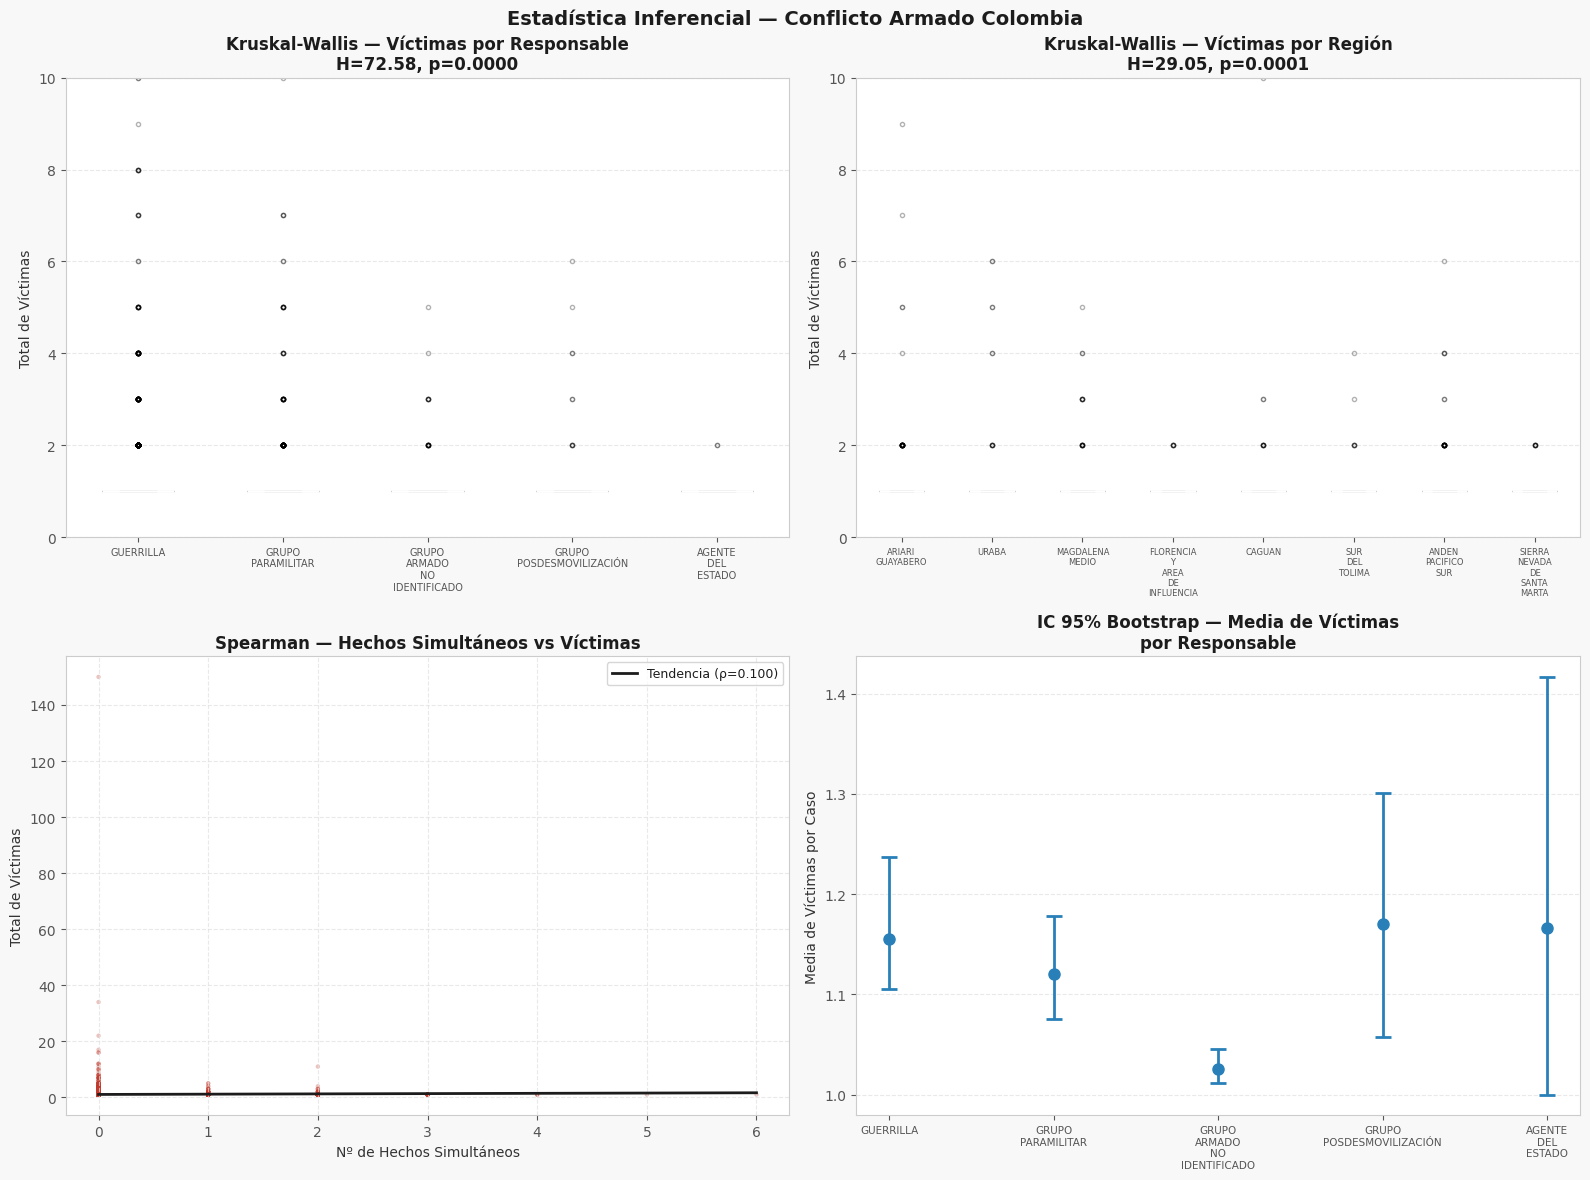

In [ ]:



# ── 9B.7 Visualización inferencial ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Estadística Inferencial — Conflicto Armado Colombia',
             fontsize=14, fontweight='bold')

# Boxplot Kruskal-Wallis responsables
ax = axes[0, 0]
bp = ax.boxplot(grupos_resp, patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch, color in zip(bp['boxes'], PALETTE[:5]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, 6))
ax.set_xticklabels([r.replace(' ', '\n') for r in top5_resp],
                   fontsize=7)
ax.set_title(f'Kruskal-Wallis — Víctimas por Responsable\n'
             f'H={stat_kw:.2f}, p={p_kw:.4f}', fontweight='bold')
ax.set_ylabel('Total de Víctimas')
ax.set_ylim(0, 10)
ax.grid(True, axis='y')

# Boxplot Kruskal-Wallis regiones
ax = axes[0, 1]
bp2 = ax.boxplot(grupos_reg, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch, color in zip(bp2['boxes'], PALETTE[:8]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(top8_reg) + 1))
ax.set_xticklabels([r.replace(' ', '\n') for r in top8_reg],
                   fontsize=6)
ax.set_title(f'Kruskal-Wallis — Víctimas por Región\n'
             f'H={stat_kr:.2f}, p={p_kr:.4f}', fontweight='bold')
ax.set_ylabel('Total de Víctimas')
ax.set_ylim(0, 10)
ax.grid(True, axis='y')

# Spearman — scatter hechos vs víctimas
ax = axes[1, 0]
ax.scatter(df['Total_Hechos'],
           df['Total de Víctimas del Caso'],
           alpha=0.3, color=RED, s=10, edgecolors='none')
z = np.polyfit(df['Total_Hechos'],
               df['Total de Víctimas del Caso'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(0, df['Total_Hechos'].max(), 100)
ax.plot(x_line, p_line(x_line), color=DARK,
        linewidth=2, label=f'Tendencia (ρ={rho:.3f})')
ax.set_title('Spearman — Hechos Simultáneos vs Víctimas',
             fontweight='bold')
ax.set_xlabel('Nº de Hechos Simultáneos')
ax.set_ylabel('Total de Víctimas')
ax.legend(fontsize=9)
ax.grid(True)

# IC Bootstrap por responsable
ax = axes[1, 1]
responsables_ic = []
medias_ic       = []
ic_bajos        = []
ic_altos        = []

for r in top5_resp:
    datos_r = df[df['Presunto Responsable'] == r]\
              ['Total de Víctimas del Caso'].values
    boot_r = bootstrap(
        (datos_r,), statistic=np.mean,
        confidence_level=0.95, n_resamples=2000,
        random_state=42, method='percentile'
    )
    responsables_ic.append(r.replace(' ', '\n'))
    medias_ic.append(np.mean(datos_r))
    ic_bajos.append(boot_r.confidence_interval.low)
    ic_altos.append(boot_r.confidence_interval.high)

errores_inf = [m - b for m, b in zip(medias_ic, ic_bajos)]
errores_sup = [a - m for m, a in zip(medias_ic, ic_altos)]

ax.errorbar(range(len(top5_resp)), medias_ic,
            yerr=[errores_inf, errores_sup],
            fmt='o', color=BLUE, capsize=6,
            capthick=2, linewidth=2, markersize=8)
ax.set_xticks(range(len(top5_resp)))
ax.set_xticklabels(responsables_ic, fontsize=7.5)
ax.set_title('IC 95% Bootstrap — Media de Víctimas\npor Responsable',
             fontweight='bold')
ax.set_ylabel('Media de Víctimas por Caso')
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

